# **CASE H — DESEMPENHO ESCOLAR**
### *Métodos de Projeção: Modelos Baseados em Árvores*
---

Este notebook responde ao **Estudo de Caso 3 — Case H (Desempenho Escolar)** em duas frentes:

1. **Predição** — qual algoritmo prevê a nota final com o menor erro possível e qual nota um novo aluno tende a obter;
2. **Interpretação** — quais características e hábitos mais influenciam a nota final, e em que direção cada um atua.

**Estratégia adotada:**

- **Etapas 1 a 11 — Comparação ampla.** Oito algoritmos baseados em árvore (**Árvore de Regressão**, **Floresta Aleatória**, **AdaBoost**, **Gradient Boosting**, **Gradient Boosting com Histogramas**, **XGBoost**, **LightGBM** e **CatBoost**) são construídos sobre a **mesma base**, a **mesma divisão treino/teste** e (exceto o CatBoost, que trata variáveis categóricas nativamente) o **mesmo pré-processamento**. Os hiperparâmetros de cada um são otimizados por **busca aleatória** (`RandomizedSearchCV`, 100 combinações) com validação cruzada de 5 partições.

- **Etapas 12 a 14 — Refinamento do campeão.** O algoritmo vencedor da comparação (**CatBoost**) passa por uma segunda rodada de otimização, agora com **busca em grade** (`GridSearchCV`) em uma vizinhança construída **ao redor dos hiperparâmetros do seu melhor modelo**. Em seguida o modelo final é escolhido, reajustado, avaliado, interpretado e aplicado à predição de novos alunos.

> **Critério único de escolha, em todas as etapas:** menor **erro médio de teste interno (RMSE na validação cruzada)** entre os modelos que respeitam o filtro de superajuste da Etapa 6 — variação de erro do treino para o teste interno *e* para o teste externo inferior a 10%. O conjunto de teste externo nunca participa da escolha: ele apenas mede o desempenho de modelos já definidos.

### **Bibliotecas**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 01 — Importação de bibliotecas
# ==============================================================================
# Instalação de bibliotecas não disponíveis na instalação padrão do Python (ex.: Google Colab)
! pip install shap xgboost lightgbm catboost

import pandas as pd                                                                # Manipulação de dados
import numpy as np                                                                 # Cálculos numéricos
import matplotlib.pyplot as plt                                                    # Visualização de dados
import seaborn as sns                                                              # Visualização de dados
import time                                                                        # Cálculo de tempo de execução
import math                                                                        # Funções matemáticas
from IPython.display import display                                                # Exibição de tabelas dentro de laços (for)

from scipy.stats import randint, uniform, loguniform                               # Distribuições aleatórias para busca de hiperparâmetros
from sklearn.compose import ColumnTransformer                                      # Transformação de colunas
from sklearn.preprocessing import OneHotEncoder                                    # Codificação one-hot de variáveis qualitativas
from sklearn.base import clone                                                     # Criação de cópias "limpas" de modelos
from sklearn.model_selection import train_test_split, KFold                        # Divisão de dados e validação cruzada
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV               # Busca aleatória (Etapa 5) e busca em grade (Etapa 12)
from sklearn.metrics import r2_score, root_mean_squared_error                      # Métricas de avaliação
from sklearn.tree import DecisionTreeRegressor, plot_tree                          # Árvore de regressão
from sklearn.ensemble import RandomForestRegressor                                 # Floresta aleatória (bagging)
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor          # Impulsionamento tradicional
from sklearn.ensemble import HistGradientBoostingRegressor                         # Impulsionamento com histogramas
from xgboost import XGBRegressor                                                   # Impulsionamento via XGBoost
from lightgbm import LGBMRegressor                                                 # Impulsionamento via LightGBM
from catboost import CatBoostRegressor                                             # Impulsionamento via CatBoost
from sklearn.inspection import permutation_importance                              # Importância de variáveis por permutação
import shap                                                                        # Interpretabilidade (cálculo e gráficos SHAP)

# Cores fixas para identificar cada algoritmo em todos os gráficos do notebook
CORES = {
    "ÁRVORE DE REGRESSÃO": "darkturquoise",
    "FLORESTA ALEATÓRIA": "darkorange",
    "ADABOOST": "gold",
    "GRADIENT BOOSTING": "mediumseagreen",
    "GRADIENT BOOSTING COM HISTOGRAMAS": "mediumpurple",
    "XGBOOST": "crimson",
    "LIGHTGBM": "royalblue",
    "CATBOOST": "sienna",
}

pd.set_option('display.float_format', '{:.3f}'.format)  # Quantidade de casas decimais na exibição de tabelas

# Foram importadas as bibliotecas de manipulação de dados (pandas/numpy), visualização estática (matplotlib/seaborn),
# modelagem (scikit-learn, xgboost, lightgbm, catboost) e interpretabilidade (shap); e definida a paleta de cores fixa
# usada para identificar cada um dos 8 algoritmos em todos os gráficos a seguir.

### **Leitura da base de dados**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 02 — Leitura da base de dados
# ==============================================================================
# Ajuste o nome do arquivo caso a sua cópia local tenha outro nome (ex.: "..._Dados-1.txt")
dados = pd.read_table("Desempenho_Escolar_Dados-1.txt",
                      sep="\t",
                      decimal=".",
                      header=0)

# A base de dados 'Desempenho_Escolar_Dados.txt' foi carregada em um data frame pandas
# chamado 'dados'. Cada linha representa um aluno (visão aluno).

### **Visualização da base de dados**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 03 — Visualização das primeiras linhas
# ==============================================================================
dados.head()

# Foram exibidas as 5 primeiras linhas da base, para inspeção inicial das colunas e valores.

,id_aluno,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,escolaridade_pais,acesso_internet_casa,participa_monitoria,atividades_extracurriculares,trabalha_alem_estudar,turno,tempo_deslocamento_min,nro_irmaos,possui_transporte_proprio,nota_final
0,A000001,19,90.700,80.600,fundamental,sim,nao,3,nao,tarde,15,3,nao,51.800
1,A000002,12,93.800,89.800,medio,nao,sim,1,nao,manha,13,3,sim,77.800
2,A000003,23,92.000,86.400,superior,sim,nao,1,nao,tarde,30,0,nao,64.100
3,A000004,15,96.200,57.800,superior,sim,nao,0,nao,tarde,1,2,nao,77.600
4,A000005,4,75.500,7.900,superior,sim,nao,1,nao,tarde,25,0,nao,9.900


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 03.1 — Estatísticas descritivas das variáveis quantitativas
# ==============================================================================
dados.describe()

# Foram exibidas as medidas de posição e dispersão das variáveis numéricas, para verificar
# escalas, valores extremos e a faixa efetiva da variável resposta (nota_final).

,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos,nota_final
count,1976.000,1976.000,1976.000,1976.000,1976.000,1976.000,1976.000
mean,14.761,85.448,65.163,1.326,26.123,1.570,64.741
std,8.808,15.232,20.766,1.158,19.208,1.258,20.476
min,0.000,32.100,1.900,0.000,1.000,0.000,6.100
25%,8.000,80.000,52.000,0.000,12.000,1.000,51.700
50%,13.000,92.000,68.300,1.000,22.000,1.000,67.800
75%,20.000,96.200,81.325,2.000,36.000,2.000,80.425
max,40.000,100.000,100.000,5.000,120.000,6.000,99.900


###  Análises de unicidade e preenchimento


*Contabilização da quantidade de valores duplicados na chave*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 03.2 — Verificação de duplicidade na chave
# ==============================================================================
# Altere o nome do(s) campo(s) chave, conforme necessário
dados[['id_aluno']].duplicated().sum()

# Foi contabilizada a quantidade de registros duplicados na chave identificadora do aluno.

np.int64(0)

*Verificação de quais registros estão duplicados na chave*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 03.3 — Registros duplicados na chave
# ==============================================================================
# Altere o nome do(s) campo(s) chave, conforme necessário
dados[dados[['id_aluno']].duplicated(keep=False)]

# Foram exibidos os registros duplicados na chave (se houver), para inspeção.

,id_aluno,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,escolaridade_pais,acesso_internet_casa,participa_monitoria,atividades_extracurriculares,trabalha_alem_estudar,turno,tempo_deslocamento_min,nro_irmaos,possui_transporte_proprio,nota_final



> Não temos valores duplicados



*Contabilização da quantidade de valores ausentes em cada variável*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 03.4 — Verificação de valores ausentes
# ==============================================================================
dados.isna().sum()

# Foi contabilizada a quantidade de valores ausentes em cada variável da base.

,0
id_aluno,0
horas_estudo_semana,0
frequencia_aulas_pct,0
media_notas_anteriores,0
escolaridade_pais,0
acesso_internet_casa,0
participa_monitoria,0
atividades_extracurriculares,0
trabalha_alem_estudar,0
turno,0




> Também não possuimos valores ausentes.


### **Dimensões da base de dados**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 04 — Dimensões da base de dados
# ==============================================================================
dados.shape

# Foi exibida a quantidade de linhas (observações) e colunas (variáveis) da base de dados.

(1976, 14)

### **Tipos das colunas da base de dados**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 05 — Tipos das colunas
# ==============================================================================
dados.dtypes

# Foi exibido o tipo de dado (numérico ou texto) de cada coluna da base.

,0
id_aluno,object
horas_estudo_semana,int64
frequencia_aulas_pct,float64
media_notas_anteriores,float64
escolaridade_pais,object
acesso_internet_casa,object
participa_monitoria,object
atividades_extracurriculares,int64
trabalha_alem_estudar,object
turno,object


### **Etapa 1: Especificação de variáveis e análise bivariada**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 06 — Especificação das variáveis explicativas
# ==============================================================================
# Variáveis explicativas quantitativas (deixar vazio [] caso não haja nenhuma)
lista_X_quanti = [
    'horas_estudo_semana',
    'frequencia_aulas_pct',
    'media_notas_anteriores',
    'atividades_extracurriculares',
    'tempo_deslocamento_min',
    'nro_irmaos'
]

# Variáveis explicativas qualitativas (deixar vazio [] caso não haja nenhuma)
lista_X_quali = [
    'escolaridade_pais',
    'acesso_internet_casa',
    'participa_monitoria',
    'trabalha_alem_estudar',
    'turno',
    'possui_transporte_proprio'
]

# Foram separadas as variáveis explicativas em duas listas — quantitativas e qualitativas — que orientam todo o
# pré-processamento e a modelagem a seguir (para todos os algoritmos, inclusive o CatBoost, que usa 'lista_X_quali'
# diretamente como 'cat_features').

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 07 — Definição de y (resposta) e X (explicativas)
# ==============================================================================
y = dados['nota_final']
X = dados[lista_X_quali + lista_X_quanti]

# Foram criados os objetos 'y' (variável resposta, Nota) e 'X' (variáveis explicativas), usados a partir daqui em
# toda a modelagem.

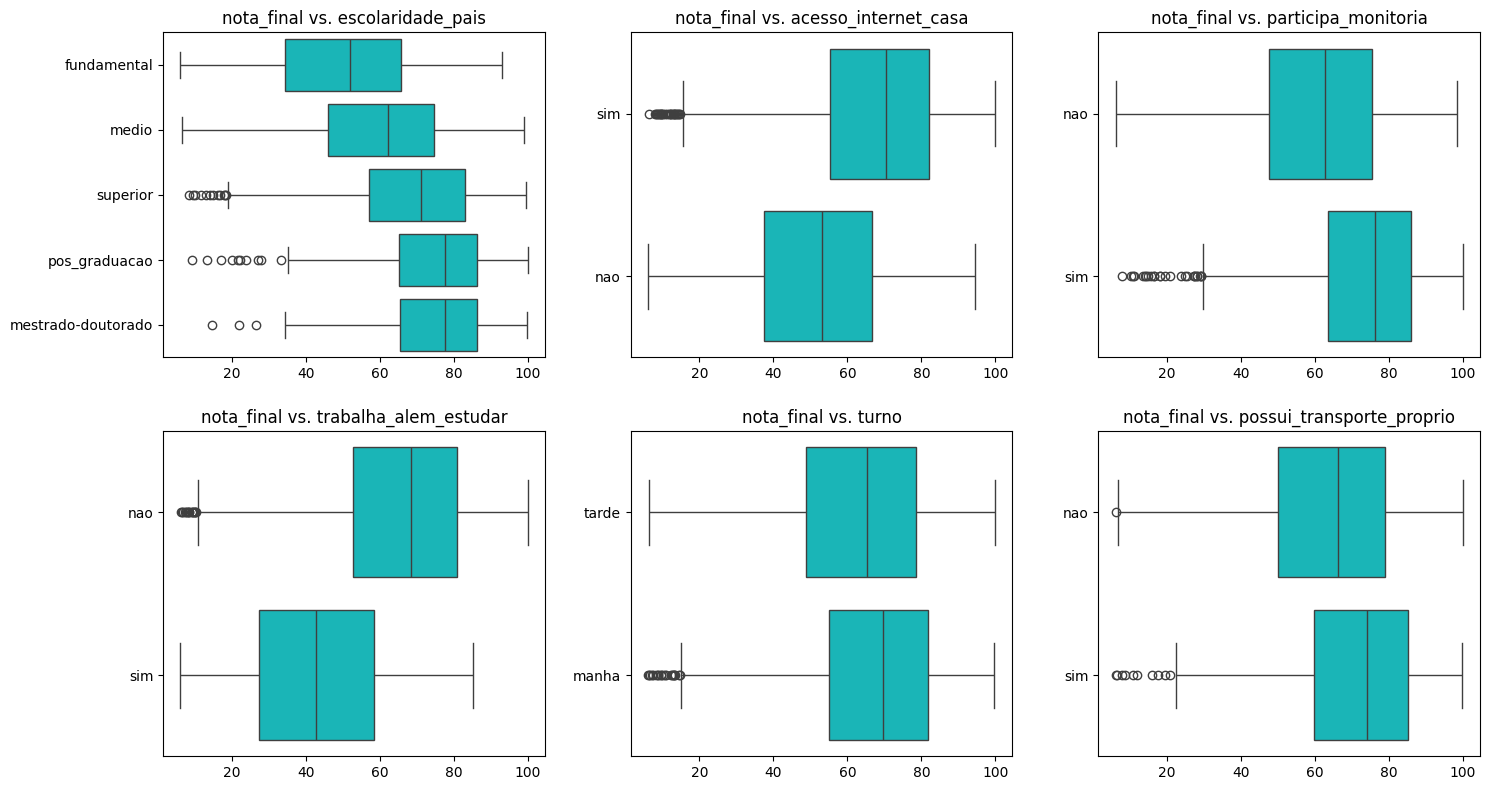

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 08 — Análise bivariada — variáveis qualitativas vs. Nota (boxplots)
# ==============================================================================
if lista_X_quali:
    n = len(lista_X_quali)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(lista_X_quali):
        sns.boxplot(y=dados[var],
                    x=y,
                    ax=axes[i],
                    orient='h',
                    color='darkturquoise')
        axes[i].set_title(f'{y.name} vs. {var}')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout(h_pad=2, w_pad=2)
    plt.show()

# Foi gerado um painel de boxplots (um por variável qualitativa) relacionando cada categoria de nota.

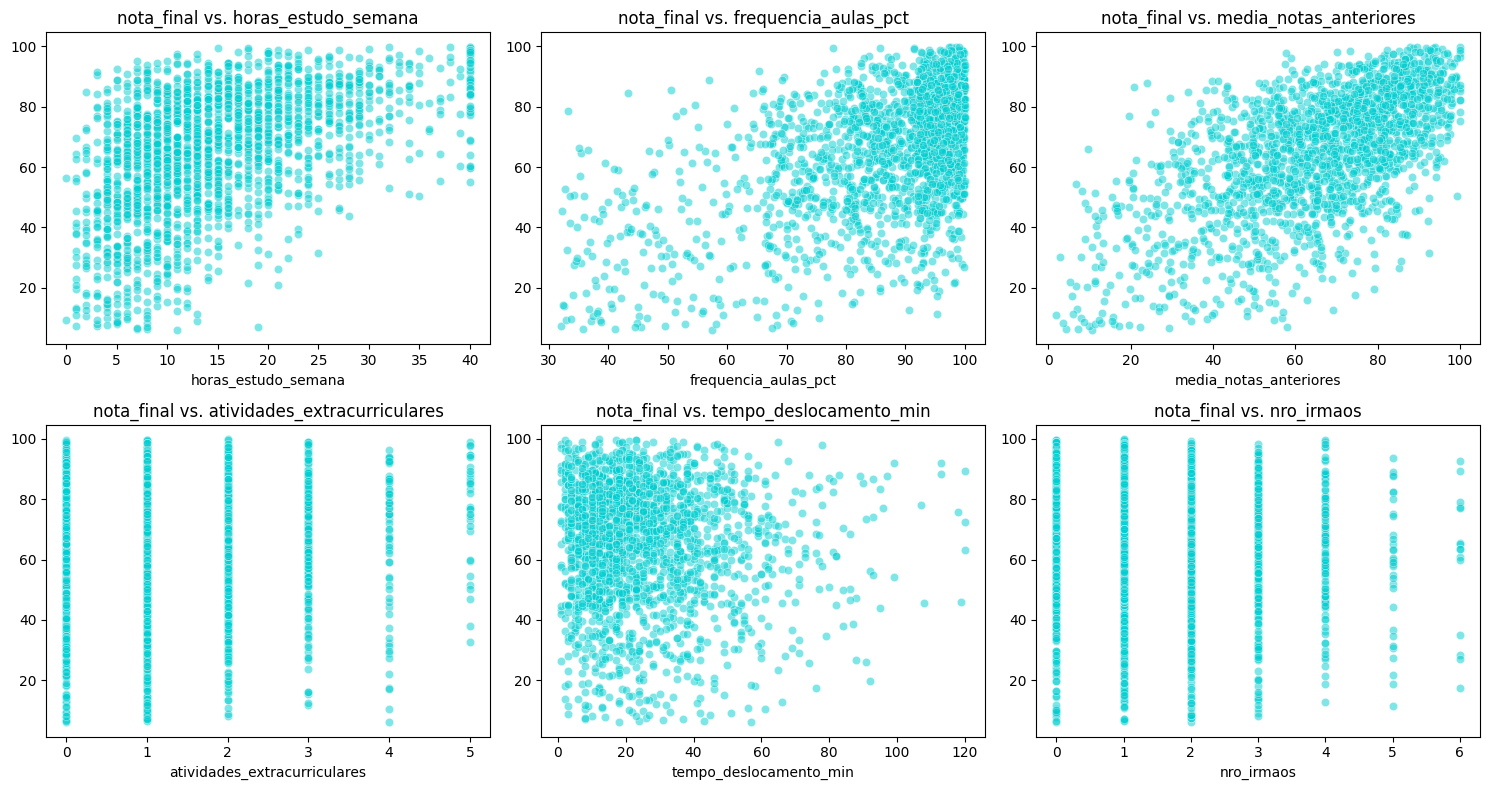

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 09 — Análise bivariada — variáveis quantitativas vs Nota
# ==============================================================================
if lista_X_quanti:
    n = len(lista_X_quanti)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(lista_X_quanti):
        sns.scatterplot(x=dados[var],
                        y=y,
                        ax=axes[i],
                        color='darkturquoise',
                        alpha=0.5)
        axes[i].set_title(f'{y.name} vs. {var}')
        axes[i].set_ylabel("")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

# Foi gerado um painel de gráficos de dispersão (um por variável quantitativa) relacionando cada variável a Nota de alunos.

### **Etapa 2: Divisão de treino e teste externo**

*A mesma divisão (mesmo `random_state`) é usada para os 8 algoritmos, garantindo que todos sejam treinados e avaliados exatamente nas mesmas observações — condição necessária para que a comparação de desempenho entre eles seja válida.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 10 — Divisão em treino e teste externo
# ==============================================================================
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=123)

# A base foi dividida em 80% treino e 20% teste externo, com semente fixa (random_state=123), garantindo que os
# 8 algoritmos comparados usem exatamente a mesma partição de dados.

### **Etapa 3: Pré-processamento de variáveis explicativas**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 11 — Definição do pré-processador
# ==============================================================================
preprocessador = ColumnTransformer(transformers=[
    # Não é necessário padronizar variáveis quantitativas em algoritmos baseados em árvores
    # ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
],
    remainder="passthrough"
)

# Foi definido um ColumnTransformer que aplica codificação one-hot às variáveis qualitativas (descartando a primeira
# categoria de cada uma) e mantém as variáveis quantitativas inalteradas. Usado por 7 dos 8 algoritmos — o CatBoost
# não passa por essa transformação (Bloco 12/13 seguintes não se aplicam a ele; ver nota após o Bloco 13).

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 12 — Ajuste do pré-processamento no treino
# ==============================================================================
X_treino_tratada = preprocessador.fit_transform(X_treino)  # O pré-processamento não deve envolver o conjunto de teste externo, que deve ficar reservado apenas para aplicações de resultados já obtidos, e nunca construções
if lista_X_quali:
    nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali))
else:
    nomes_quali = []
nomes_variaveis = nomes_quali + list(lista_X_quanti)

X_treino_tratada = pd.DataFrame(X_treino_tratada, columns=nomes_variaveis)
X_treino_tratada.head()

# O pré-processador foi ajustado ('fit') apenas no conjunto de treino e aplicado ('transform') a ele mesmo, gerando
# 'X_treino_tratada' com os nomes finais das variáveis (dummies das qualitativas + quantitativas).

,escolaridade_pais_medio,escolaridade_pais_mestrado-doutorado,escolaridade_pais_pos_graduacao,escolaridade_pais_superior,acesso_internet_casa_sim,participa_monitoria_sim,trabalha_alem_estudar_sim,turno_tarde,possui_transporte_proprio_sim,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos
0,0.000,0.000,1.000,0.000,1.000,1.000,0.000,1.000,0.000,10.000,82.200,21.400,3.000,12.000,2.000
1,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,8.000,70.200,63.700,1.000,12.000,2.000
2,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,8.000,93.200,39.300,1.000,27.000,3.000
3,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,9.000,98.200,18.800,1.000,2.000,2.000
4,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,11.000,93.100,42.400,0.000,9.000,5.000


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 13 — Aplicação do pré-processamento no teste externo
# ==============================================================================
X_teste_tratada = preprocessador.transform(X_teste)  # O mesmo objeto de pré-processamento é reutilizado, agora com 'transform' em vez de 'fit_transform'
X_teste_tratada = pd.DataFrame(X_teste_tratada, columns=nomes_variaveis)
X_teste_tratada.head()

# O mesmo objeto 'preprocessador' (já ajustado no treino) foi reutilizado, agora apenas com 'transform', para gerar
# 'X_teste_tratada' — evitando qualquer vazamento de informação do teste externo para o pré-processamento.

,escolaridade_pais_medio,escolaridade_pais_mestrado-doutorado,escolaridade_pais_pos_graduacao,escolaridade_pais_superior,acesso_internet_casa_sim,participa_monitoria_sim,trabalha_alem_estudar_sim,turno_tarde,possui_transporte_proprio_sim,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos
0,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,39.000,94.400,65.400,1.000,19.000,1.000
1,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,4.000,88.300,51.700,2.000,8.000,2.000
2,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,3.000,32.900,54.900,0.000,51.000,3.000
3,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,17.000,77.000,35.700,2.000,27.000,1.000
4,0.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,8.000,51.900,35.400,1.000,6.000,0.000


> `X_treino_tratada` e `X_teste_tratada` (codificadas via one-hot) são usadas pela **Árvore de Regressão**, **Floresta Aleatória**, **AdaBoost**, **Gradient Boosting**, **Gradient Boosting com Histogramas**, **XGBoost** e **LightGBM**. O **CatBoost** usa `X_treino`/`X_teste` **sem** codificação (variáveis categóricas em seu formato original), pois trata variáveis categóricas nativamente por meio do parâmetro `cat_features=lista_X_quali`, repassado em cada chamada `.fit(...)` ao longo do notebook.

### **Etapa 4: Definição dos algoritmos e intervalos de busca de hiperparâmetros**

*Os hiperparâmetros de estrutura de árvore (`max_depth`, mínimos de observações por nó etc.) são mantidos com faixas comparáveis entre os algoritmos, na medida do que cada implementação expõe. Cada entrada do dicionário `algoritmos` é uma tupla `(classe_algoritmo, hiperparametros, tipo_dado)`, em que `tipo_dado` indica se o algoritmo usa os dados **tratados** (one-hot) ou **brutos** (`'raw'`, apenas o CatBoost) — essa informação orienta os laços de treino, avaliação e interpretabilidade das etapas seguintes.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 14 — Definição dos algoritmos e hiperparâmetros
# ==============================================================================
algoritmos = {

    'ÁRVORE DE REGRESSÃO': (DecisionTreeRegressor(random_state=123), {
        'min_impurity_decrease': uniform(0, 0.05),     # Percentual mínimo de redução de impureza
        'min_samples_split': randint(100, 200),        # Qtde. mínima de observações no nó "pai"
        'min_samples_leaf': randint(50, 100),          # Qtde. mínima de observações no nó "filho"
        'max_depth': randint(2, 10)                    # Profundidade máxima da árvore
    }, 'tratada'),

    'FLORESTA ALEATÓRIA': (RandomForestRegressor(random_state=123, n_jobs=-1), {
        'n_estimators': randint(10, 500),               # Qtde. de árvores na floresta
        'min_impurity_decrease': uniform(0, 0.05),      # Percentual mínimo de redução de impureza
        'min_samples_split': randint(50, 200),          # Qtde. mínima de observações no nó "pai"
        'min_samples_leaf': randint(20, 50),            # Qtde. mínima de observações no nó "filho"
        'max_samples': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'max_features': ['sqrt', 'log2', None],         # Qtde. de variáveis consideradas em cada quebra
        'max_depth': randint(2, 10)                     # Profundidade máxima das árvores
    }, 'tratada'),

    'ADABOOST': (AdaBoostRegressor(random_state=123), {
        'n_estimators': randint(10, 300),               # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1)         # Taxa de aprendizado
    }, 'tratada'),

    'GRADIENT BOOSTING': (GradientBoostingRegressor(random_state=123), {
        'n_estimators': randint(10, 300),               # Qtde. de árvores no boosting
        'min_impurity_decrease': uniform(0, 0.05),      # Percentual mínimo de redução de impureza
        'learning_rate': loguniform(1e-4, 1e-1),        # Taxa de aprendizado
        'min_samples_split': randint(100, 300),         # Qtde. mínima de observações no nó "pai"
        'min_samples_leaf': randint(50, 100),           # Qtde. mínima de observações no nó "filho"
        'subsample': uniform(0.6, 0.4),                 # Percentual de observações consideradas em cada árvore
        'max_features': ['sqrt', 'log2', None],         # Qtde. de variáveis consideradas em cada árvore
        'max_depth': randint(2, 10)                     # Profundidade máxima das árvores
    }, 'tratada'),

    'GRADIENT BOOSTING COM HISTOGRAMAS': (HistGradientBoostingRegressor(random_state=123), {
        'max_iter': randint(10, 300),                   # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),        # Taxa de aprendizado
        'min_samples_leaf': randint(50, 100),           # Qtde. mínima de observações no nó "filho"
        'max_leaf_nodes': randint(10, 50),              # Qtde. máxima de nós finais
        'max_bins': randint(10, 255),                   # Qtde. máxima de bins para discretização
        'l2_regularization': loguniform(1e-5, 1e2),     # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 10)                     # Profundidade máxima das árvores
    }, 'tratada'),

    'XGBOOST': (XGBRegressor(random_state=123, n_jobs=-1, enable_categorical=False), {
        'n_estimators': randint(10, 300),               # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),        # Taxa de aprendizado
        'colsample_bytree': uniform(0.5, 0.5),          # Percentual de variáveis consideradas em cada árvore
        'subsample': uniform(0.6, 0.4),                 # Percentual de observações consideradas em cada árvore
        'gamma': uniform(0, 5),                         # Redução mínima na função de perda para realizar uma quebra
        'reg_alpha': loguniform(1e-5, 1e2),             # Contribuição da penalização LASSO (L1)
        'reg_lambda': loguniform(1e-5, 1e2),            # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 10)                     # Profundidade máxima das árvores
    }, 'tratada'),

    'LIGHTGBM': (LGBMRegressor(random_state=123, n_jobs=-1, verbosity=-1), {
        'n_estimators': randint(10, 300),               # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),        # Taxa de aprendizado
        'min_child_samples': randint(50, 100),          # Qtde. mínima de observações no nó "filho"
        'num_leaves': randint(10, 50),                  # Qtde. máxima de nós finais
        'subsample': uniform(0.6, 0.4),                 # Percentual de observações consideradas em cada árvore
        'reg_alpha': loguniform(1e-5, 1e2),             # Contribuição da penalização LASSO (L1)
        'reg_lambda': loguniform(1e-5, 1e2),            # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 10)                     # Profundidade máxima das árvores
    }, 'tratada'),

    'CATBOOST': (CatBoostRegressor(random_state=123, logging_level='Silent'), {
        'iterations': randint(10, 200),                 # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),        # Taxa de aprendizado
        'subsample': uniform(0.6, 0.4),                 # Percentual de observações consideradas em cada árvore
        'l2_leaf_reg': loguniform(1e-5, 1e2),           # Contribuição da penalização Ridge (L2)
        'depth': randint(2, 8)                          # Profundidade máxima das árvores
    }, 'raw'),

}

# Foi criado o dicionário 'algoritmos' com os 8 algoritmos a comparar; para cada um, as distribuições de busca de
# hiperparâmetros e a indicação de qual conjunto de dados ('tratada' = one-hot, 'raw' = bruto, com cat_features)
# deve ser usado nas etapas de treino, avaliação e interpretabilidade a seguir.

### **Etapa 5: Construção de modelos usando validação cruzada, busca aleatória e teste externo**

*Para reduzir o tempo de execução em um primeiro teste, reduza `qtd_iteracoes` abaixo (ex.: para 10), ou comente temporariamente algoritmos mais custosos (Floresta Aleatória, Gradient Boosting, XGBoost) no dicionário `algoritmos` do Bloco 14.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 15 — Estratégia de validação cruzada
# ==============================================================================
kf = KFold(n_splits=5, shuffle=True, random_state=123)
qtd_iteracoes = 100

# Foi definida a estratégia de validação cruzada (K-Fold com 5 partições) e a quantidade máxima de combinações de
# hiperparâmetros testadas por algoritmo (100).

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 16 — Construção dos modelos (busca aleatória + teste externo)
# ==============================================================================
resultados = []         # Lista para armazenar resultados
contador_modelos = 0    # Contador de modelos testados

for nome_algoritmo, (classe_algoritmo, hiperparametros, tipo_dado) in algoritmos.items():

    # Início da contagem de tempo
    inicio = time.time()

    # Seleção do conjunto de dados e de parâmetros extras de 'fit', conforme o tipo de algoritmo
    if tipo_dado == 'tratada':
        X_treino_uso, X_teste_uso = X_treino_tratada, X_teste_tratada
        fit_kwargs = {}
    else:  # 'raw' — apenas CatBoost, que trata variáveis categóricas nativamente
        X_treino_uso, X_teste_uso = X_treino, X_teste
        fit_kwargs = {'cat_features': lista_X_quali}

    # Busca aleatória de hiperparâmetros com validação cruzada (randomized search)
    busca = RandomizedSearchCV(
        estimator=classe_algoritmo,
        param_distributions=hiperparametros,
        n_iter=1 if not hiperparametros else qtd_iteracoes,
        scoring='neg_root_mean_squared_error',
        cv=kf,
        return_train_score=True,
        random_state=123,
        n_jobs=-1
    )

    # Ajuste dos modelos
    busca.fit(X_treino_uso, y_treino, **fit_kwargs)

    # Armazenar os resultados da busca
    resultados_aux = pd.DataFrame({
        "num_modelo": [f"Modelo {contador_modelos + i}" for i in range(len(busca.cv_results_["params"]))],
        "nome_algoritmo": nome_algoritmo,
        "classe_algoritmo": type(classe_algoritmo).__name__,
        "hiperparametros": busca.cv_results_["params"],
        "media_erro_treino": -busca.cv_results_["mean_train_score"],
        "media_erro_teste_interno": -busca.cv_results_["mean_test_score"],
        "dp_erro_treino": busca.cv_results_["std_train_score"],
        "dp_erro_teste_interno": busca.cv_results_["std_test_score"]
    })

    # Calcular erro no teste externo, para cada modelo
    erro_teste = []
    for params in resultados_aux["hiperparametros"]:
        estimador = clone(classe_algoritmo).set_params(**params)
        estimador.fit(X_treino_uso, y_treino, **fit_kwargs)
        y_hat_teste = estimador.predict(X_teste_uso)
        erro = root_mean_squared_error(y_teste, y_hat_teste)
        erro_teste.append(erro)

    # Adicionar coluna de erro em teste externo e colunas de variações (absoluta e percentual) de erro em relação ao treino
    resultados_aux["erro_teste_externo"] = erro_teste
    resultados_aux["var_abs_media_erro_teste_interno"] = abs(resultados_aux["media_erro_teste_interno"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_perc_media_erro_teste_interno"] = resultados_aux["var_abs_media_erro_teste_interno"] / resultados_aux["media_erro_treino"]
    resultados_aux["var_abs_erro_teste_externo"] = abs(resultados_aux["erro_teste_externo"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_perc_erro_teste_externo"] = resultados_aux["var_abs_erro_teste_externo"] / resultados_aux["media_erro_treino"]

    resultados.append(resultados_aux)
    contador_modelos += len(resultados_aux)

    # Fim da contagem de tempo e mensagem de finalização
    fim = time.time()
    print(f"({list(algoritmos).index(nome_algoritmo) + 1} de {len(algoritmos)}) Processo concluído para o algoritmo {nome_algoritmo} em {fim - inicio:.1f} segundos!")

# Criação de data frame único com os resultados dos 8 algoritmos
resultados = pd.concat(resultados, ignore_index=True)

# Para cada um dos 8 algoritmos, foi feita uma busca aleatória de hiperparâmetros (RandomizedSearchCV) com validação
# cruzada de 5 folds, usando o conjunto de dados apropriado ('tratada' ou 'raw'); cada combinação testada também foi
# reajustada no treino completo e avaliada no teste externo. Todos os resultados foram empilhados em um único data
# frame 'resultados', o que já viabiliza a comparação direta entre eles.

(1 de 8) Processo concluído para o algoritmo ÁRVORE DE REGRESSÃO em 16.2 segundos!
(2 de 8) Processo concluído para o algoritmo FLORESTA ALEATÓRIA em 401.1 segundos!
(3 de 8) Processo concluído para o algoritmo ADABOOST em 392.1 segundos!
(4 de 8) Processo concluído para o algoritmo GRADIENT BOOSTING em 138.2 segundos!
(5 de 8) Processo concluído para o algoritmo GRADIENT BOOSTING COM HISTOGRAMAS em 97.8 segundos!
(6 de 8) Processo concluído para o algoritmo XGBOOST em 131.5 segundos!
(7 de 8) Processo concluído para o algoritmo LIGHTGBM em 114.2 segundos!
(8 de 8) Processo concluído para o algoritmo CATBOOST em 97.8 segundos!


### **Etapa 6: Comparação de modelos**

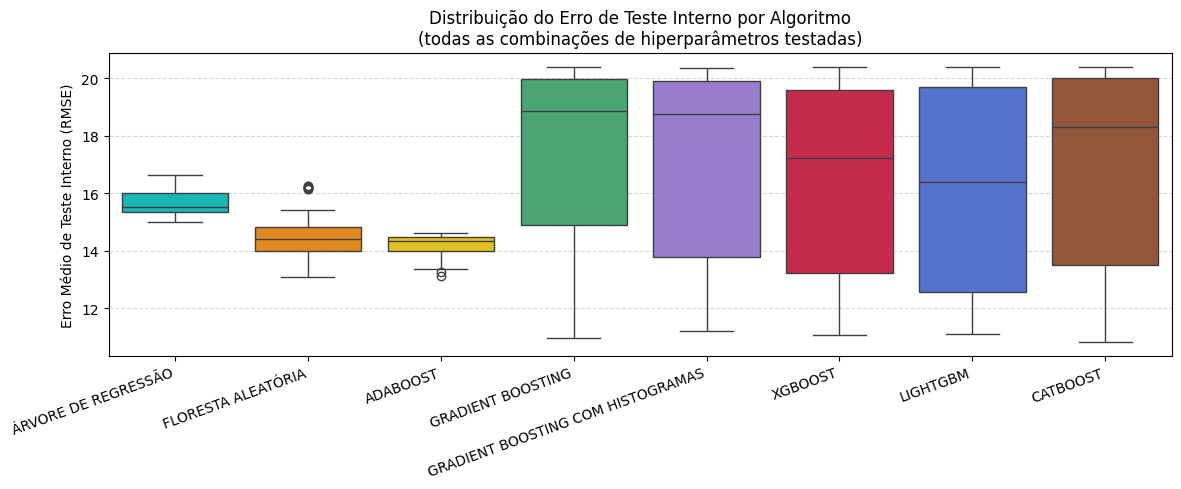

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 17 — Distribuição do erro de teste interno por algoritmo
# ==============================================================================
plt.figure(figsize=(12, 5))
sns.boxplot(data=resultados, x="nome_algoritmo", y="media_erro_teste_interno",
            hue="nome_algoritmo", palette=CORES, legend=False)
plt.title("Distribuição do Erro de Teste Interno por Algoritmo\n(todas as combinações de hiperparâmetros testadas)")
plt.xlabel("")
plt.ylabel("Erro Médio de Teste Interno (RMSE)")
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Foi construído um boxplot comparando a distribuição do erro de teste interno entre os 8 algoritmos, considerando
# todas as combinações de hiperparâmetros testadas na busca aleatória de cada um.

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 18 — Ordenação e filtragem dos melhores modelos
# ==============================================================================
# Escolha por qual coluna ordenar
ordenar_por = "media_erro_teste_interno"
# ordenar_por = "var_abs_media_erro_teste_interno"
# ordenar_por = "var_abs_erro_teste_externo"

# Escolha os percentuais máximos de variação de erro (da média do treino para a média do teste interno; e da média do treino para o teste externo)
max_var_perc_erro_teste_interno = 0.1
max_var_perc_erro_teste_externo = 0.1

# Ordenação e filtragem
resultados_filt_ord = resultados[(resultados['var_abs_perc_media_erro_teste_interno'] < max_var_perc_erro_teste_interno) &
                                  (resultados['var_abs_perc_erro_teste_externo'] < max_var_perc_erro_teste_externo)]
resultados_filt_ord = resultados_filt_ord.sort_values(ordenar_por, ascending=True)

# Os modelos foram filtrados, mantendo apenas aqueles cuja variação percentual de erro (do treino para o teste
# interno, e do treino para o teste externo) é inferior a 10%, e em seguida ordenados pelo erro médio de teste interno.

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 19 — Tabela com os 10 melhores modelos (entre os 8 algoritmos)
# ==============================================================================
resultados_filt_ord[['num_modelo',
                     'nome_algoritmo',
                     'hiperparametros',
                     'media_erro_treino',
                     'dp_erro_treino',
                     'media_erro_teste_interno',
                     'dp_erro_teste_interno',
                     'var_abs_perc_media_erro_teste_interno',
                     'erro_teste_externo',
                     'var_abs_perc_erro_teste_externo']].head(10)   # Escolha quantos modelos quer exibir

# Foi exibida a tabela com os 10 melhores modelos, considerando os 8 algoritmos em conjunto.

,num_modelo,nome_algoritmo,hiperparametros,media_erro_treino,dp_erro_treino,media_erro_teste_interno,dp_erro_teste_interno,var_abs_perc_media_erro_teste_interno,erro_teste_externo,var_abs_perc_erro_teste_externo
777,Modelo 777,CATBOOST,"{'depth': 3, 'iterations': 193, 'l2_leaf_reg':...",10.705,0.103,11.313,0.395,0.057,11.411,0.066
715,Modelo 715,CATBOOST,"{'depth': 3, 'iterations': 97, 'l2_leaf_reg': ...",10.919,0.102,11.532,0.404,0.056,11.583,0.061
766,Modelo 766,CATBOOST,"{'depth': 2, 'iterations': 105, 'l2_leaf_reg':...",11.644,0.113,12.040,0.380,0.034,12.320,0.058
724,Modelo 724,CATBOOST,"{'depth': 2, 'iterations': 129, 'l2_leaf_reg':...",11.695,0.105,12.100,0.362,0.035,12.273,0.049
321,Modelo 321,GRADIENT BOOSTING,"{'learning_rate': 0.03010338844193861, 'max_de...",11.504,0.109,12.185,0.435,0.059,12.599,0.095
716,Modelo 716,CATBOOST,"{'depth': 5, 'iterations': 48, 'l2_leaf_reg': ...",11.500,0.092,12.207,0.411,0.061,12.402,0.078
395,Modelo 395,GRADIENT BOOSTING,"{'learning_rate': 0.013517427298922231, 'max_d...",11.641,0.127,12.209,0.319,0.049,12.550,0.078
747,Modelo 747,CATBOOST,"{'depth': 4, 'iterations': 138, 'l2_leaf_reg':...",11.705,0.093,12.244,0.429,0.046,12.511,0.069
798,Modelo 798,CATBOOST,"{'depth': 4, 'iterations': 91, 'l2_leaf_reg': ...",11.831,0.086,12.342,0.445,0.043,12.520,0.058
335,Modelo 335,GRADIENT BOOSTING,"{'learning_rate': 0.056298522688241454, 'max_d...",11.589,0.104,12.397,0.477,0.070,12.675,0.094


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 20 — Tabela com os melhores modelos de cada algoritmo
# ==============================================================================
melhores_por_algoritmo = (resultados_filt_ord
                           .sort_values("media_erro_teste_interno")
                           .groupby("nome_algoritmo")
                           .head(3))

melhores_por_algoritmo[['num_modelo',
                        'nome_algoritmo',
                        'hiperparametros',
                        'media_erro_treino',
                        'media_erro_teste_interno',
                        'erro_teste_externo']].sort_values(['nome_algoritmo', 'media_erro_teste_interno'])

# Foi exibida, lado a lado, a tabela com os 3 melhores modelos de cada um dos 8 algoritmos separadamente.

,num_modelo,nome_algoritmo,hiperparametros,media_erro_treino,media_erro_teste_interno,erro_teste_externo
261,Modelo 261,ADABOOST,"{'learning_rate': 0.08930847112671622, 'n_esti...",12.253,13.114,13.222
283,Modelo 283,ADABOOST,"{'learning_rate': 0.06063588752822365, 'n_esti...",12.355,13.253,13.472
245,Modelo 245,ADABOOST,"{'learning_rate': 0.04218454832079112, 'n_esti...",12.466,13.362,13.486
777,Modelo 777,CATBOOST,"{'depth': 3, 'iterations': 193, 'l2_leaf_reg':...",10.705,11.313,11.411
715,Modelo 715,CATBOOST,"{'depth': 3, 'iterations': 97, 'l2_leaf_reg': ...",10.919,11.532,11.583
766,Modelo 766,CATBOOST,"{'depth': 2, 'iterations': 105, 'l2_leaf_reg':...",11.644,12.040,12.320
149,Modelo 149,FLORESTA ALEATÓRIA,"{'max_depth': 8, 'max_features': None, 'max_sa...",12.020,13.081,13.092
173,Modelo 173,FLORESTA ALEATÓRIA,"{'max_depth': 6, 'max_features': None, 'max_sa...",12.142,13.189,13.134
124,Modelo 124,FLORESTA ALEATÓRIA,"{'max_depth': 8, 'max_features': None, 'max_sa...",12.543,13.441,13.373
321,Modelo 321,GRADIENT BOOSTING,"{'learning_rate': 0.03010338844193861, 'max_de...",11.504,12.185,12.599


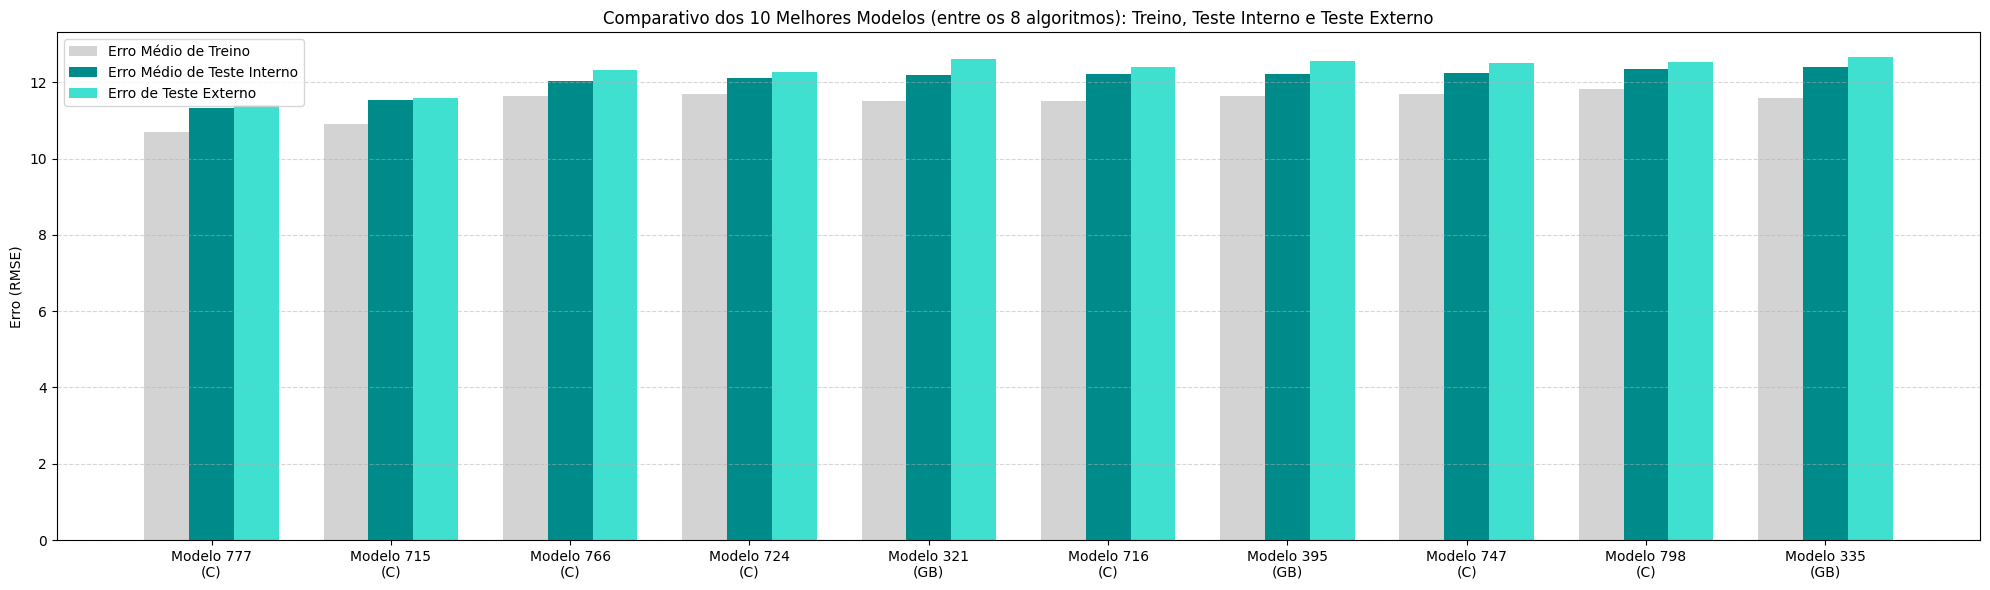

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 21 — Gráfico com os melhores modelos: treino, teste interno e teste externo
# ==============================================================================
dados_grafico = resultados_filt_ord.sort_values("media_erro_teste_interno").head(10).copy()   # Escolha quantos modelos quer exibir

abrev = {nome: "".join(p[0] for p in nome.split()) for nome in algoritmos}   # Sigla curta (iniciais) por algoritmo
dados_grafico["rotulo"] = dados_grafico["num_modelo"] + "\n(" + dados_grafico["nome_algoritmo"].map(abrev) + ")"

x_pos = np.arange(len(dados_grafico))     # Posições dos rótulos do eixo X
largura_barra = 0.25                      # Largura das barras

plt.figure(figsize=(20, 6))
plt.bar(x_pos - largura_barra,            # Série com erro médio de treino
        dados_grafico["media_erro_treino"],
        width=largura_barra,
        label="Erro Médio de Treino",
        color="lightgray")
plt.bar(x_pos,                            # Série com erro médio de teste interno
        dados_grafico["media_erro_teste_interno"],
        width=largura_barra,
        label="Erro Médio de Teste Interno",
        color="darkcyan")
plt.bar(x_pos + largura_barra,            # Série com erro médio de teste externo
        dados_grafico["erro_teste_externo"],
        width=largura_barra,
        label="Erro de Teste Externo",
        color="turquoise")

plt.xticks(x_pos, dados_grafico["rotulo"], rotation=0, ha='center')
plt.ylabel("Erro (RMSE)")
plt.title("Comparativo dos 10 Melhores Modelos (entre os 8 algoritmos): Treino, Teste Interno e Teste Externo")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Foi construído um gráfico de barras comparando o erro de treino, teste interno e teste externo dos 10 melhores
# modelos (entre todos os algoritmos), identificados pelas iniciais do algoritmo de origem.

### **Etapa 7: Escolha do modelo final de cada algoritmo**

*Para cada algoritmo, seleciona-se automaticamente o modelo com menor erro médio de teste interno entre os que respeitam o critério de filtragem da Etapa 6 — tornando a escolha reprodutível a cada execução.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 22 — Seleção automática do modelo final de cada algoritmo
# ==============================================================================
modelos_escolhidos = (resultados_filt_ord
                       .sort_values("media_erro_teste_interno")
                       .groupby("nome_algoritmo")
                       .first())

for nome_algoritmo, linha in modelos_escolhidos.iterrows():
    hiperparametros_fmt = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in linha["hiperparametros"].items()}
    print(f"[{nome_algoritmo}] {linha['num_modelo']} — hiperparâmetros: {hiperparametros_fmt}")

# Foi selecionado, para cada algoritmo, o modelo de menor erro médio de teste interno entre os aprovados no filtro
# da Etapa 6, e os hiperparâmetros de cada modelo escolhido foram impressos.

[ADABOOST] Modelo 261 — hiperparâmetros: {'learning_rate': np.float64(0.0893), 'n_estimators': 205}
[CATBOOST] Modelo 777 — hiperparâmetros: {'depth': 3, 'iterations': 193, 'l2_leaf_reg': np.float64(0.1789), 'learning_rate': np.float64(0.0273), 'subsample': np.float64(0.7342)}
[FLORESTA ALEATÓRIA] Modelo 149 — hiperparâmetros: {'max_depth': 8, 'max_features': None, 'max_samples': np.float64(0.6833), 'min_impurity_decrease': np.float64(0.0222), 'min_samples_leaf': 20, 'min_samples_split': 53, 'n_estimators': 233}
[GRADIENT BOOSTING] Modelo 321 — hiperparâmetros: {'learning_rate': np.float64(0.0301), 'max_depth': 5, 'max_features': None, 'min_impurity_decrease': np.float64(0.0003), 'min_samples_leaf': 98, 'min_samples_split': 156, 'n_estimators': 110, 'subsample': np.float64(0.611)}
[GRADIENT BOOSTING COM HISTOGRAMAS] Modelo 441 — hiperparâmetros: {'l2_regularization': np.float64(0.3859), 'learning_rate': np.float64(0.0175), 'max_bins': 22, 'max_depth': 4, 'max_iter': 102, 'max_leaf_node

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 23 — Comparação de configuração (hiperparâmetros)
# ==============================================================================
config_comparativa = pd.DataFrame({
    nome_algoritmo: pd.Series(linha["hiperparametros"])
    for nome_algoritmo, linha in modelos_escolhidos.iterrows()
})
config_comparativa

# Foi montada a tabela comparativa de configuração: os hiperparâmetros do modelo final escolhido em cada um dos 8
# algoritmos, lado a lado (células em branco indicam hiperparâmetro não aplicável àquele algoritmo).

,ADABOOST,CATBOOST,FLORESTA ALEATÓRIA,GRADIENT BOOSTING,GRADIENT BOOSTING COM HISTOGRAMAS,LIGHTGBM,XGBOOST,ÁRVORE DE REGRESSÃO
colsample_bytree,NaN,NaN,NaN,NaN,NaN,NaN,0.508,NaN
depth,NaN,3.000,NaN,NaN,NaN,NaN,NaN,NaN
gamma,NaN,NaN,NaN,NaN,NaN,NaN,1.128,NaN
iterations,NaN,193.000,NaN,NaN,NaN,NaN,NaN,NaN
l2_leaf_reg,NaN,0.179,NaN,NaN,NaN,NaN,NaN,NaN
l2_regularization,NaN,NaN,NaN,NaN,0.386,NaN,NaN,NaN
learning_rate,0.089,0.027,NaN,0.030,0.017,0.011,0.025,NaN
max_bins,NaN,NaN,NaN,NaN,22.000,NaN,NaN,NaN
max_depth,NaN,NaN,8.000,5.000,4.000,5.000,2.000,8.000
max_features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 24 — Retreino dos modelos finais no treino completo
# ==============================================================================
modelos_finais = {}
for nome_algoritmo, linha in modelos_escolhidos.iterrows():
    classe_algoritmo, _, tipo_dado = algoritmos[nome_algoritmo]
    hiperparametros = linha["hiperparametros"]
    X_treino_uso = X_treino_tratada if tipo_dado == 'tratada' else X_treino
    fit_kwargs = {} if tipo_dado == 'tratada' else {'cat_features': lista_X_quali}

    modelo = clone(classe_algoritmo).set_params(**hiperparametros)
    modelo.fit(X_treino_uso, y_treino, **fit_kwargs)
    modelos_finais[nome_algoritmo] = modelo

modelos_finais

# Cada um dos 8 modelos finais foi reajustado no conjunto de treino completo apropriado (tratado ou bruto), com os
# hiperparâmetros escolhidos, e armazenado no dicionário 'modelos_finais'.

{'ADABOOST': AdaBoostRegressor(learning_rate=np.float64(0.08930847112671622),
                   n_estimators=205, random_state=123),
 'CATBOOST': CatBoostRegressor(depth=3, iterations=193, l2_leaf_reg=np.float64(0.17893837775831142), learning_rate=np.float64(0.027280978122794227), logging_level='Silent', loss_function='RMSE', random_state=123, subsample=np.float64(0.7342175494157145)),
 'FLORESTA ALEATÓRIA': RandomForestRegressor(max_depth=8, max_features=None,
                       max_samples=np.float64(0.6832993186955747),
                       min_impurity_decrease=np.float64(0.02216838509006059),
                       min_samples_leaf=20, min_samples_split=53,
                       n_estimators=233, n_jobs=-1, random_state=123),
 'GRADIENT BOOSTING': GradientBoostingRegressor(learning_rate=np.float64(0.03010338844193861),
                           max_depth=5,
                           min_impurity_decrease=np.float64(0.0002676644193168154),
                           min_s

### **Etapa 8: Visualização estrutural dos modelos**

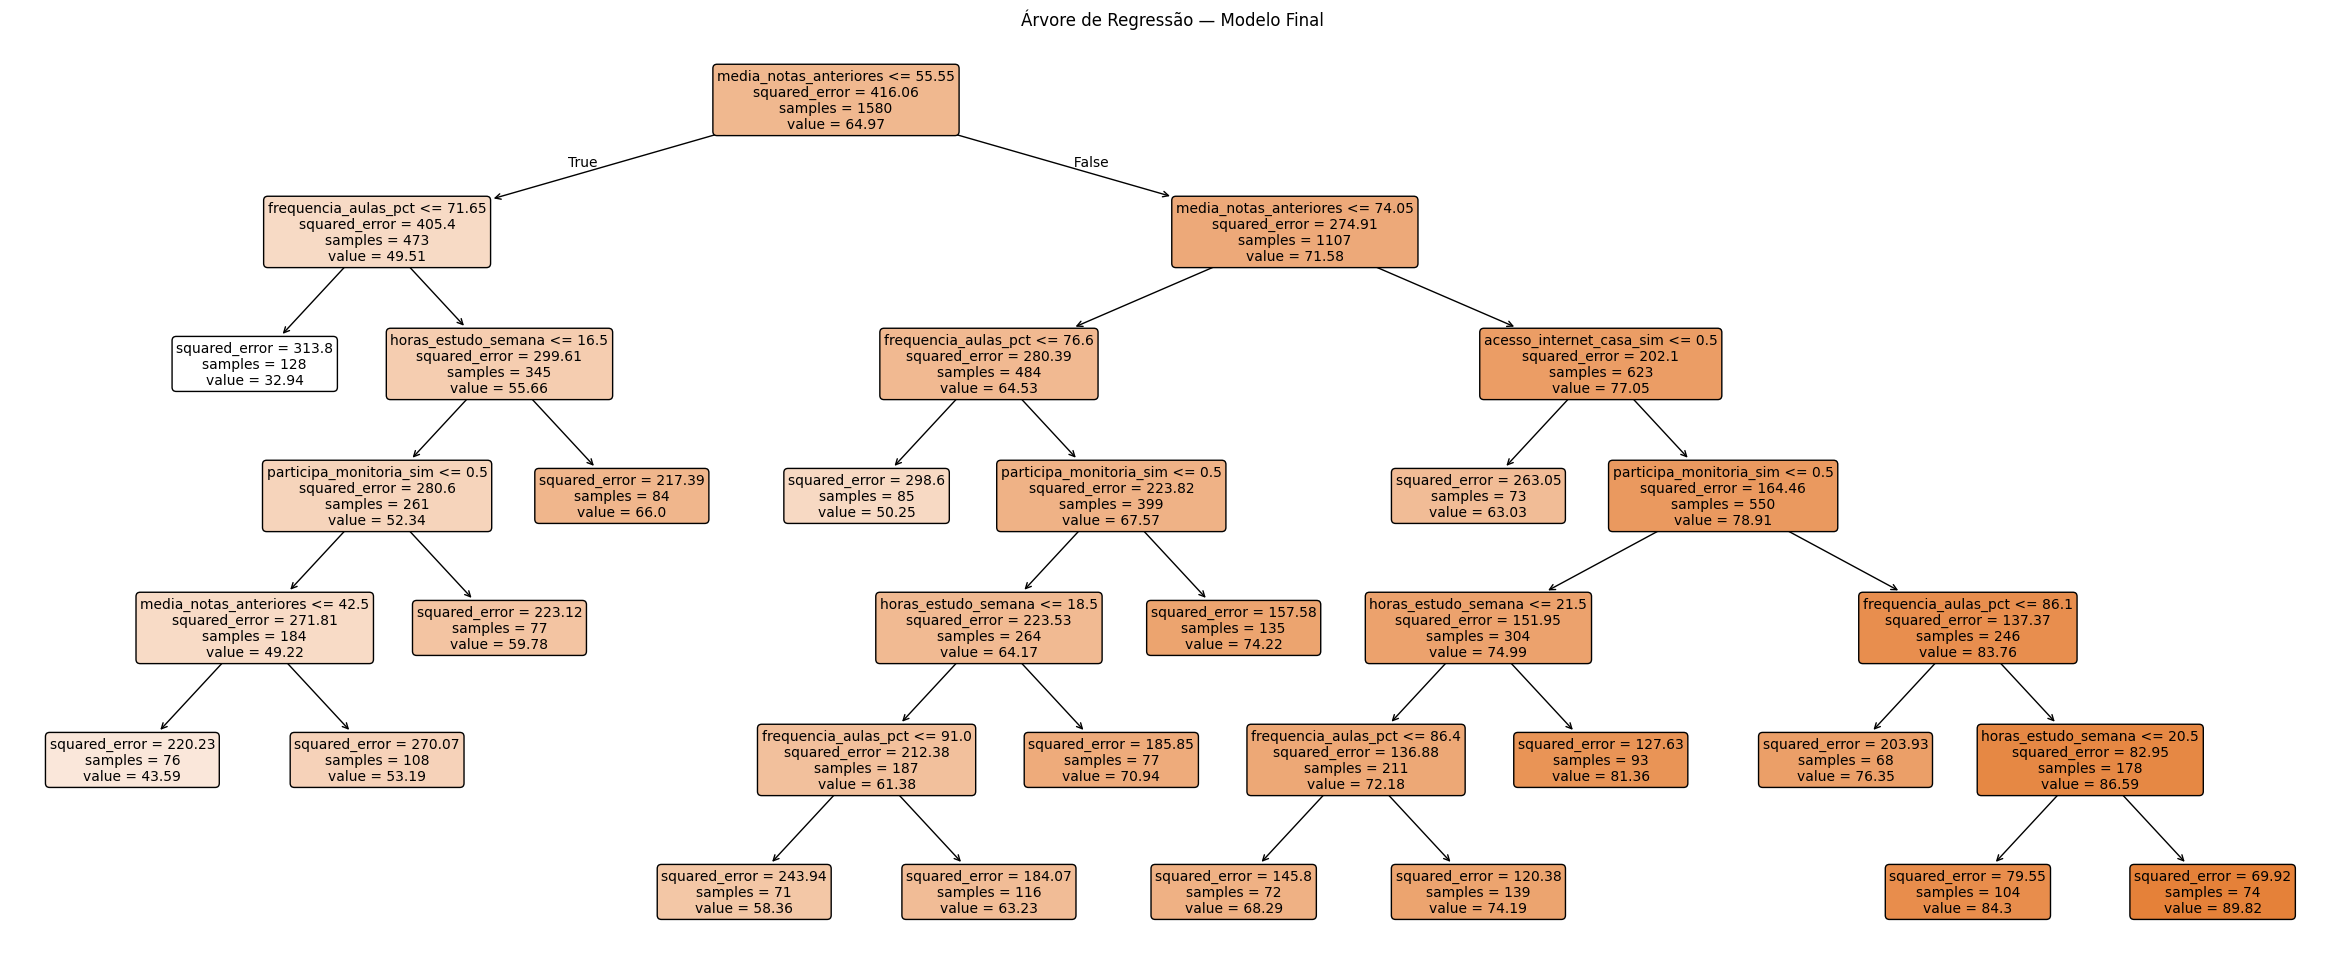

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 25 — Estrutura da Árvore de Regressão final
# ==============================================================================
plt.figure(figsize=(30, 12))                        # Ajuste o tamanho da figura para obter uma melhor visualização, a depender do tamanho da árvore
plot_tree(modelos_finais['ÁRVORE DE REGRESSÃO'],
          feature_names=X_treino_tratada.columns,   # Nomes das variáveis
          filled=True,                              # Cores de preenchimento dos nós
          fontsize=10,                              # Tamanho da fonte dos nós
          rounded=True,                              # Arredondamento de valores nos nós
          precision=2)                              # Precisão do arredondamento
plt.title("Árvore de Regressão — Modelo Final")
plt.show()

# Foi desenhada, com 'plot_tree' do scikit-learn, a estrutura completa da Árvore de Regressão final.

*A Floresta Aleatória, o AdaBoost e o Gradient Boosting são compostos por dezenas ou centenas de árvores; abaixo é exibida, apenas a título ilustrativo, a primeira árvore de cada ensemble (limitada a 3 níveis para ficar legível) — isoladamente ela não representa o modelo, que combina as previsões de todas as árvores (por média, no caso da Floresta, ou por soma ponderada, no caso dos dois boostings).*

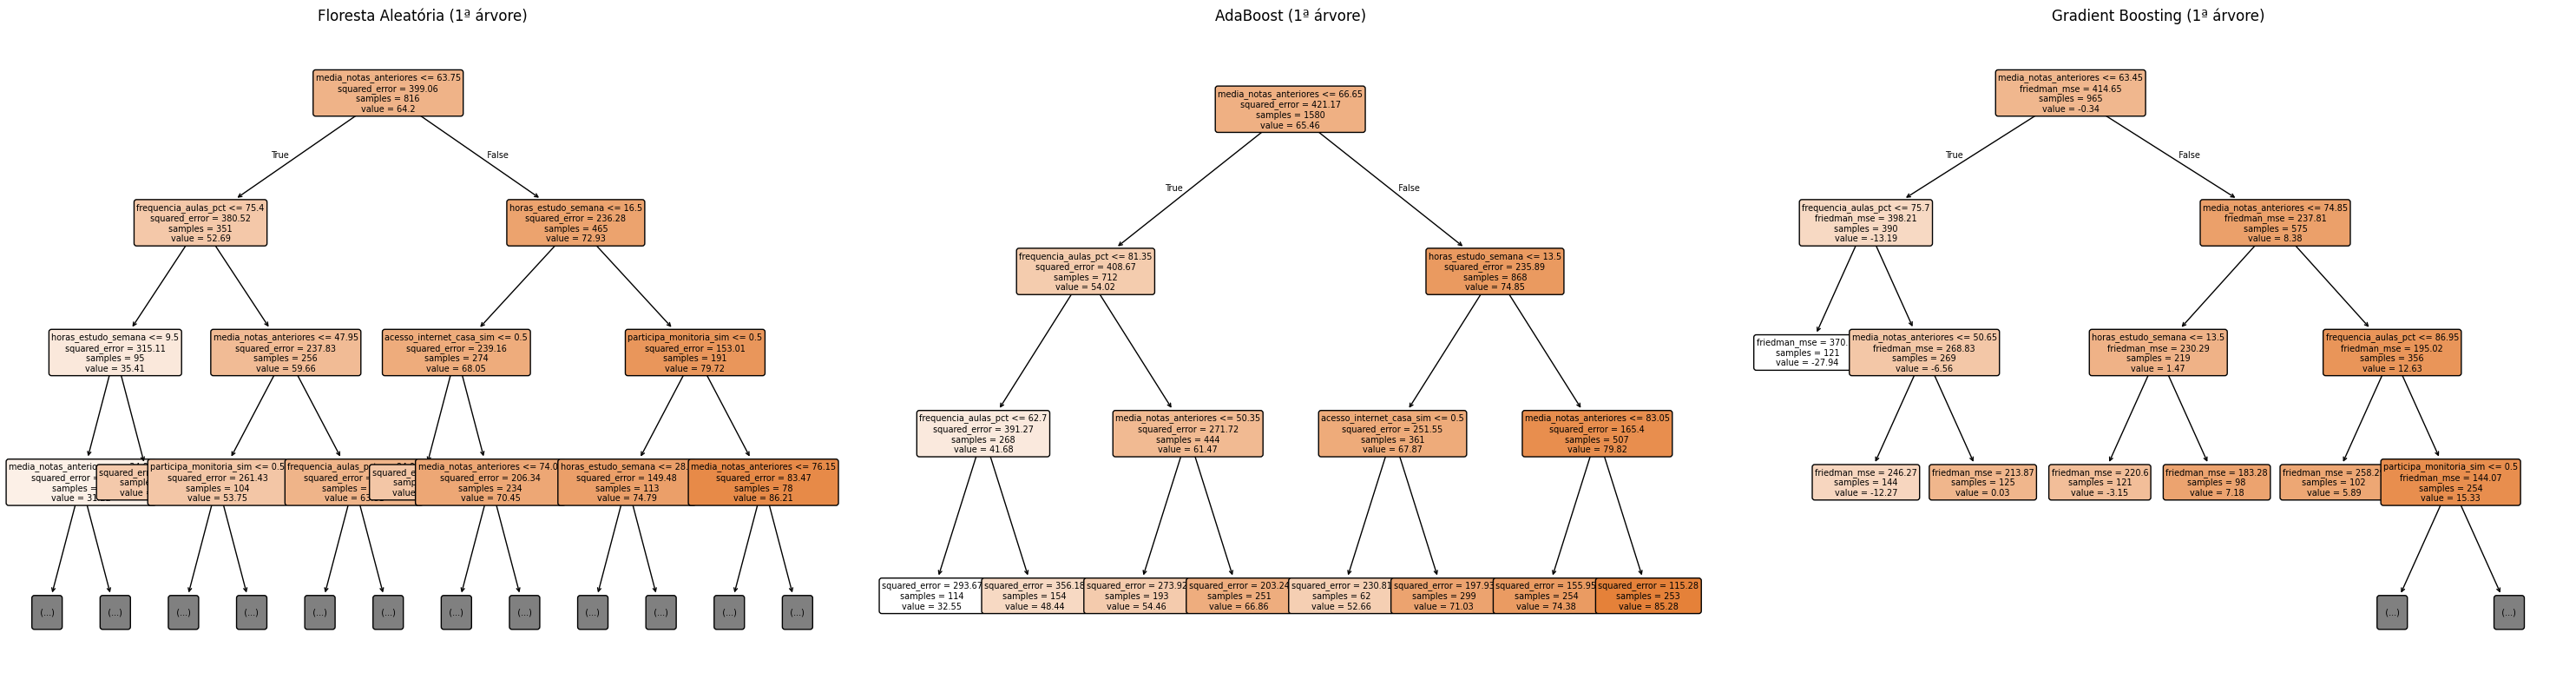

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 26 — Estrutura ilustrativa de uma árvore de cada ensemble baseado em sklearn
# ==============================================================================
rf_final = modelos_finais['FLORESTA ALEATÓRIA']
ada_final = modelos_finais['ADABOOST']
gb_final = modelos_finais['GRADIENT BOOSTING']

primeiras_arvores = {
    "Floresta Aleatória (1ª árvore)": rf_final.estimators_[0],
    "AdaBoost (1ª árvore)": ada_final.estimators_[0],
    "Gradient Boosting (1ª árvore)": gb_final.estimators_[0, 0],
}

fig, axes = plt.subplots(1, 3, figsize=(30, 8))
for ax, (titulo, arvore) in zip(axes, primeiras_arvores.items()):
    plot_tree(arvore,
              feature_names=X_treino_tratada.columns,
              filled=True,
              fontsize=7,
              rounded=True,
              precision=2,
              max_depth=3,     # Limitada a 3 níveis apenas para tornar a ilustração legível
              ax=ax)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

# Foram desenhadas, com 'plot_tree', a primeira árvore de cada um dos três ensembles baseados em DecisionTreeRegressor
# (Floresta Aleatória, AdaBoost e Gradient Boosting), limitadas a 3 níveis de profundidade a título ilustrativo.

*A Gradient Boosting com Histogramas, o XGBoost, o LightGBM e o CatBoost usam representações internas de árvore próprias de cada biblioteca (não compatíveis com o `plot_tree` do scikit-learn), cada uma com sua própria função de visualização (`lightgbm.plot_tree`, `xgboost.plot_tree`, o visualizador nativo do CatBoost). Para manter o notebook enxuto e sem dependências extras (ex.: `graphviz`), a estrutura interna dessas árvores não é desenhada aqui; a comparação de complexidade entre os 8 algoritmos é feita de forma numérica no bloco a seguir.*

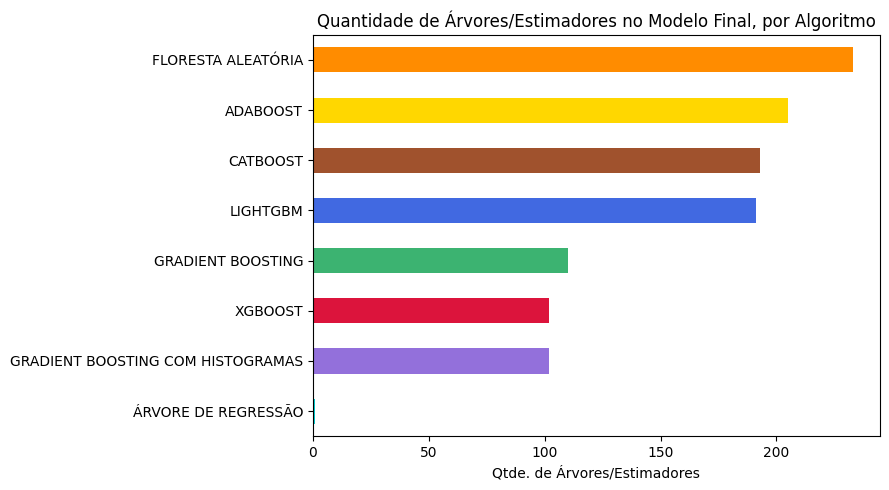

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 27 — Quantidade de árvores/estimadores no modelo final, por algoritmo
# ==============================================================================
def obter_qtd_estimadores(nome, modelo):
    if nome == 'ÁRVORE DE REGRESSÃO':
        return 1
    elif nome == 'FLORESTA ALEATÓRIA':
        return modelo.n_estimators
    elif nome == 'ADABOOST':
        return len(modelo.estimators_)
    elif nome == 'GRADIENT BOOSTING':
        return getattr(modelo, 'n_estimators_', modelo.n_estimators)
    elif nome == 'GRADIENT BOOSTING COM HISTOGRAMAS':
        return modelo.n_iter_
    elif nome == 'XGBOOST':
        return modelo.n_estimators
    elif nome == 'LIGHTGBM':
        return getattr(modelo, 'n_estimators_', modelo.n_estimators)
    elif nome == 'CATBOOST':
        return modelo.tree_count_

qtd_estimadores = pd.Series({
    nome: obter_qtd_estimadores(nome, modelo) for nome, modelo in modelos_finais.items()
}).sort_values()

qtd_estimadores.plot.barh(
    figsize=(9, 5),
    color=[CORES[c] for c in qtd_estimadores.index]
)
plt.title("Quantidade de Árvores/Estimadores no Modelo Final, por Algoritmo")
plt.xlabel("Qtde. de Árvores/Estimadores")
plt.tight_layout()
plt.show()

# Foi extraída, de cada modelo final, a quantidade efetiva de árvores/estimadores usando o atributo correspondente
# de cada biblioteca (ex.: 'n_estimators' no scikit-learn/XGBoost, 'n_iter_' no HistGradientBoosting, 'tree_count_'
# no CatBoost), e construído um gráfico de barras horizontais comparando essa complexidade entre os 8 algoritmos.

### **Etapa 9: Avaliação e comparação de desempenho no teste externo**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 28 — Predições dos modelos finais no teste externo
# ==============================================================================
predicoes_teste = {}
for nome, modelo in modelos_finais.items():
    tipo_dado = algoritmos[nome][2]
    X_teste_uso = X_teste_tratada if tipo_dado == 'tratada' else X_teste
    predicoes_teste[nome] = modelo.predict(X_teste_uso)

# Cada modelo final foi aplicado ao conjunto de teste externo apropriado (tratado ou bruto), gerando as predições
# usadas nas análises de desempenho a seguir.

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 29 — Tabela comparativa de métricas de erro no teste externo
# ==============================================================================
metricas = {}
for nome, y_hat_teste in predicoes_teste.items():
    metricas[nome] = {
        "RMSE": root_mean_squared_error(y_teste, y_hat_teste),
        "MAE": np.mean(np.abs(y_teste - y_hat_teste)),
        "MAPE": np.mean(np.abs((y_teste - y_hat_teste) / y_teste)),
        "R²": r2_score(y_teste, y_hat_teste)
    }

metricas_teste_externo = pd.DataFrame(metricas)
metricas_teste_externo

# Foram calculadas, para cada modelo final, as métricas RMSE, MAE, MAPE e R² no conjunto de teste externo,
# consolidadas em uma única tabela comparativa com os 8 algoritmos.

,ADABOOST,CATBOOST,FLORESTA ALEATÓRIA,GRADIENT BOOSTING,GRADIENT BOOSTING COM HISTOGRAMAS,LIGHTGBM,XGBOOST,ÁRVORE DE REGRESSÃO
RMSE,13.222,11.411,13.092,12.599,13.858,13.050,13.777,14.760
MAE,10.435,8.897,10.206,9.696,10.843,10.157,10.843,11.578
MAPE,0.267,0.225,0.265,0.260,0.301,0.278,0.295,0.293
R²,0.593,0.697,0.601,0.631,0.553,0.604,0.559,0.493


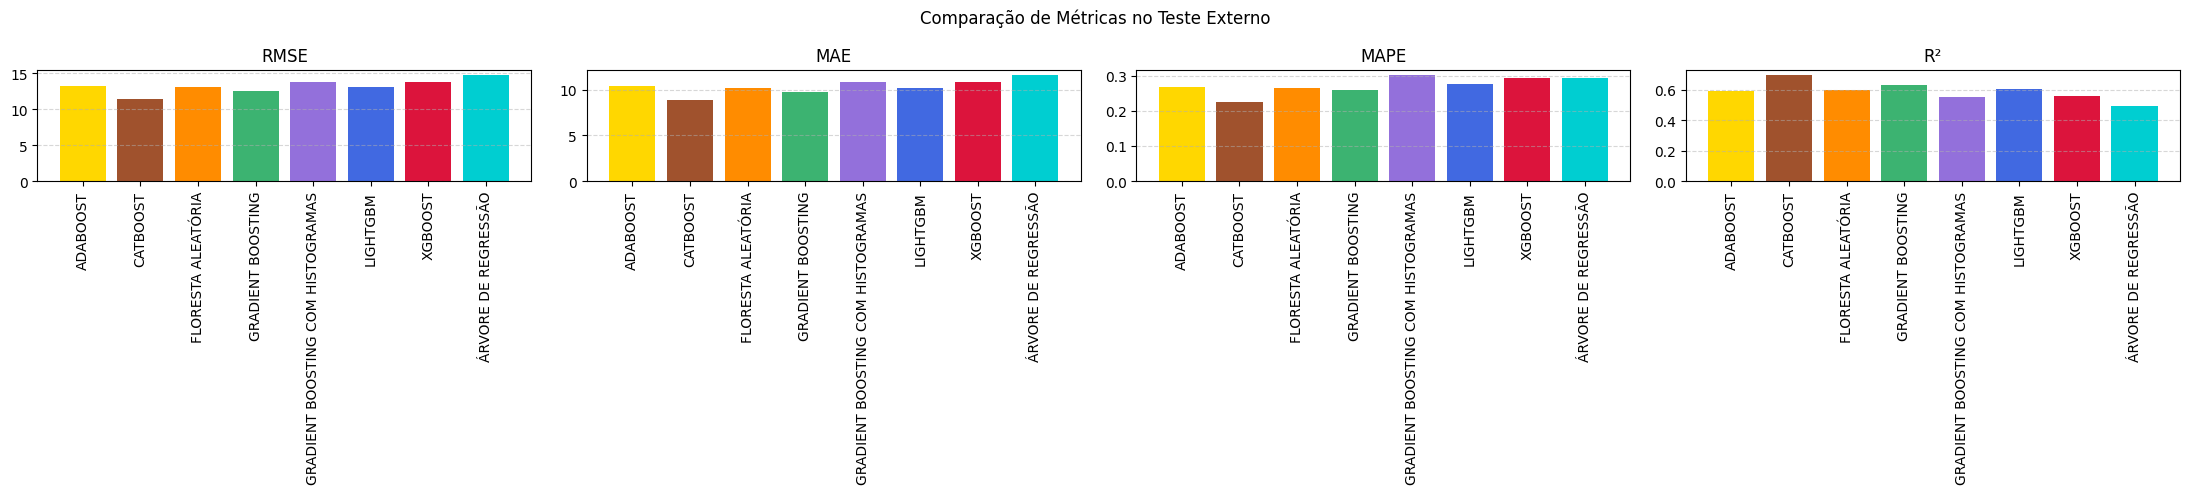

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 30 — Gráfico comparativo das métricas de teste externo
# ==============================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metrica in zip(axes, metricas_teste_externo.index):
    valores = metricas_teste_externo.loc[metrica]
    ax.bar(valores.index, valores.values, color=[CORES[c] for c in valores.index])
    ax.set_title(metrica)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Comparação de Métricas no Teste Externo")
plt.tight_layout()
plt.show()

# Foi construído um painel com 4 gráficos de barras (um por métrica — RMSE, MAE, MAPE, R²), já que estão em escalas
# diferentes, permitindo comparar visualmente os 8 algoritmos em cada métrica.

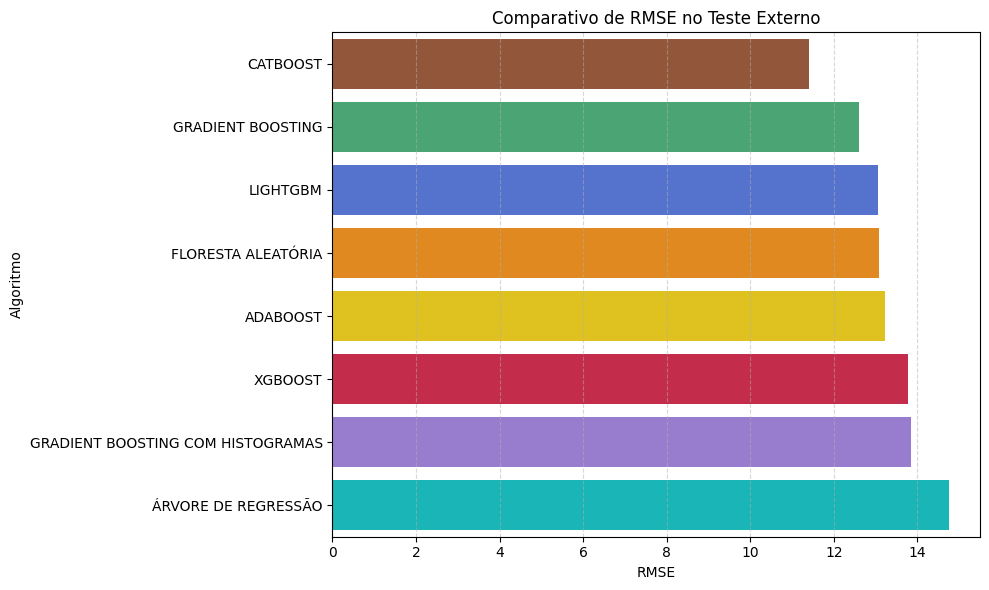

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 30.1 — Gráfico comparativo de RMSE no teste externo
# ==============================================================================
rmse_values = metricas_teste_externo.loc['RMSE'].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
# 'hue' é obrigatório para usar 'palette' nas versões recentes do seaborn
sns.barplot(x=rmse_values.values, y=rmse_values.index,
            hue=rmse_values.index, palette=[CORES[c] for c in rmse_values.index], legend=False)
plt.title("Comparativo de RMSE no Teste Externo")
plt.xlabel("RMSE")
plt.ylabel("Algoritmo")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Foi gerado um gráfico de barras horizontais ordenado pelo RMSE no teste externo, deixando
# imediatamente visível qual algoritmo prevê a nota final com o menor erro.

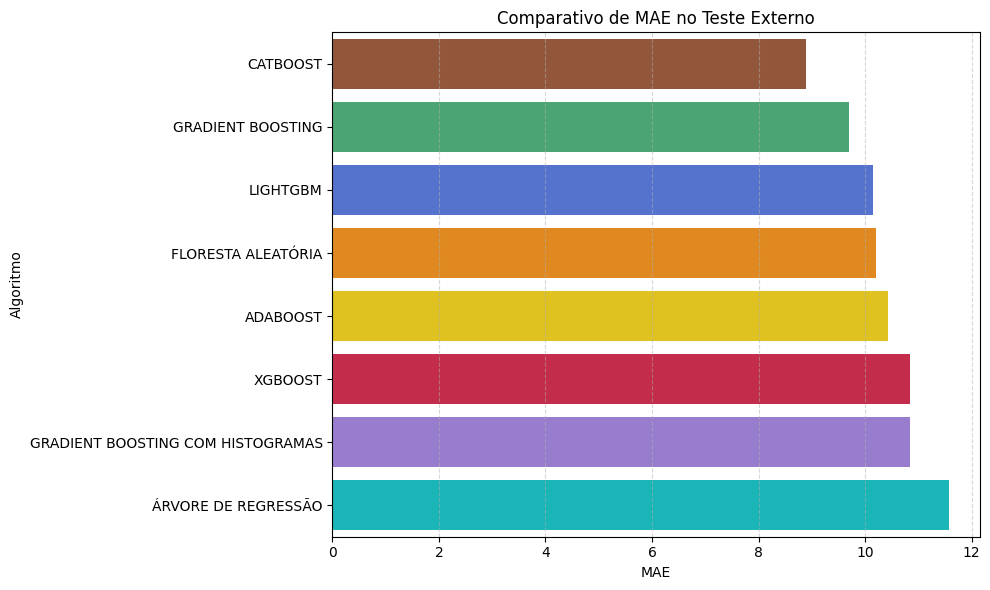

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 30.2 — Gráfico comparativo de MAE no teste externo
# ==============================================================================
mae_values = metricas_teste_externo.loc['MAE'].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=mae_values.values, y=mae_values.index,
            hue=mae_values.index, palette=[CORES[c] for c in mae_values.index], legend=False)
plt.title("Comparativo de MAE no Teste Externo")
plt.xlabel("MAE")
plt.ylabel("Algoritmo")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Foi gerado o mesmo comparativo em termos de MAE (erro absoluto médio), métrica menos
# sensível a observações extremas do que o RMSE.

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 31 — Tabela consolidada de desempenho (treino, teste interno e teste externo)
# ==============================================================================
desempenho_consolidado = pd.DataFrame({
    nome_algoritmo: {
        "Erro Médio de Treino (RMSE)": linha["media_erro_treino"],
        "DP Erro de Treino": linha["dp_erro_treino"],
        "Erro Médio de Teste Interno (RMSE)": linha["media_erro_teste_interno"],
        "DP Erro de Teste Interno": linha["dp_erro_teste_interno"],
        "Erro de Teste Externo (RMSE)": linha["erro_teste_externo"],
        "MAE Teste Externo": metricas_teste_externo.loc["MAE", nome_algoritmo],
        "MAPE Teste Externo": metricas_teste_externo.loc["MAPE", nome_algoritmo],
        "R² Teste Externo": metricas_teste_externo.loc["R²", nome_algoritmo],
    }
    for nome_algoritmo, linha in modelos_escolhidos.iterrows()
})
desempenho_consolidado

# Foi montada a tabela consolidada de desempenho, reunindo em um único lugar as métricas de treino, teste interno
# (validação cruzada) e teste externo dos 8 modelos finais.

,ADABOOST,CATBOOST,FLORESTA ALEATÓRIA,GRADIENT BOOSTING,GRADIENT BOOSTING COM HISTOGRAMAS,LIGHTGBM,XGBOOST,ÁRVORE DE REGRESSÃO
Erro Médio de Treino (RMSE),12.253,10.705,12.020,11.504,12.697,11.904,12.840,14.067
DP Erro de Treino,0.123,0.103,0.130,0.109,0.131,0.155,0.128,0.187
Erro Médio de Teste Interno (RMSE),13.114,11.313,13.081,12.185,13.441,12.882,13.421,15.010
DP Erro de Teste Interno,0.560,0.395,0.732,0.435,0.519,0.500,0.423,0.911
Erro de Teste Externo (RMSE),13.222,11.411,13.092,12.599,13.858,13.050,13.777,14.760
MAE Teste Externo,10.435,8.897,10.206,9.696,10.843,10.157,10.843,11.578
MAPE Teste Externo,0.267,0.225,0.265,0.260,0.301,0.278,0.295,0.293
R² Teste Externo,0.593,0.697,0.601,0.631,0.553,0.604,0.559,0.493


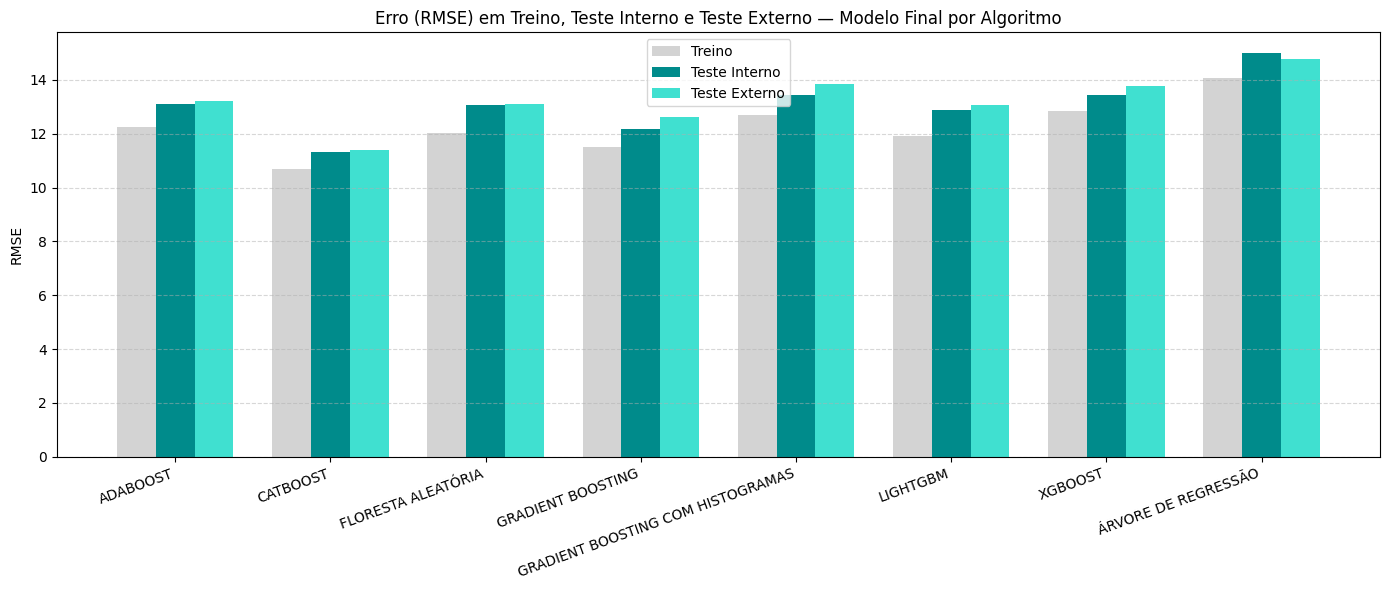

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 32 — Gráfico comparativo de RMSE em treino, teste interno e teste externo
# ==============================================================================
labels = list(modelos_escolhidos.index)

plt.figure(figsize=(14, 6))
x_pos = np.arange(len(labels))
largura_barra = 0.25

plt.bar(x_pos - largura_barra, [modelos_escolhidos.loc[l, "media_erro_treino"] for l in labels],
        width=largura_barra, label="Treino", color="lightgray")
plt.bar(x_pos, [modelos_escolhidos.loc[l, "media_erro_teste_interno"] for l in labels],
        width=largura_barra, label="Teste Interno", color="darkcyan")
plt.bar(x_pos + largura_barra, [modelos_escolhidos.loc[l, "erro_teste_externo"] for l in labels],
        width=largura_barra, label="Teste Externo", color="turquoise")

plt.xticks(x_pos, labels, rotation=20, ha='right')
plt.ylabel("RMSE")
plt.title("Erro (RMSE) em Treino, Teste Interno e Teste Externo — Modelo Final por Algoritmo")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Foi construído um gráfico de barras comparando o RMSE de treino, teste interno e teste externo entre os 8
# modelos finais, lado a lado.

### **Etapa 10: Diagnóstico de resíduos comparativo**

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 33 — Cálculo dos resíduos
# ==============================================================================
residuos = {nome: (y_teste - y_hat_teste) for nome, y_hat_teste in predicoes_teste.items()}

# Foram calculados os resíduos (valor observado menos valor predito) de cada modelo no teste externo.

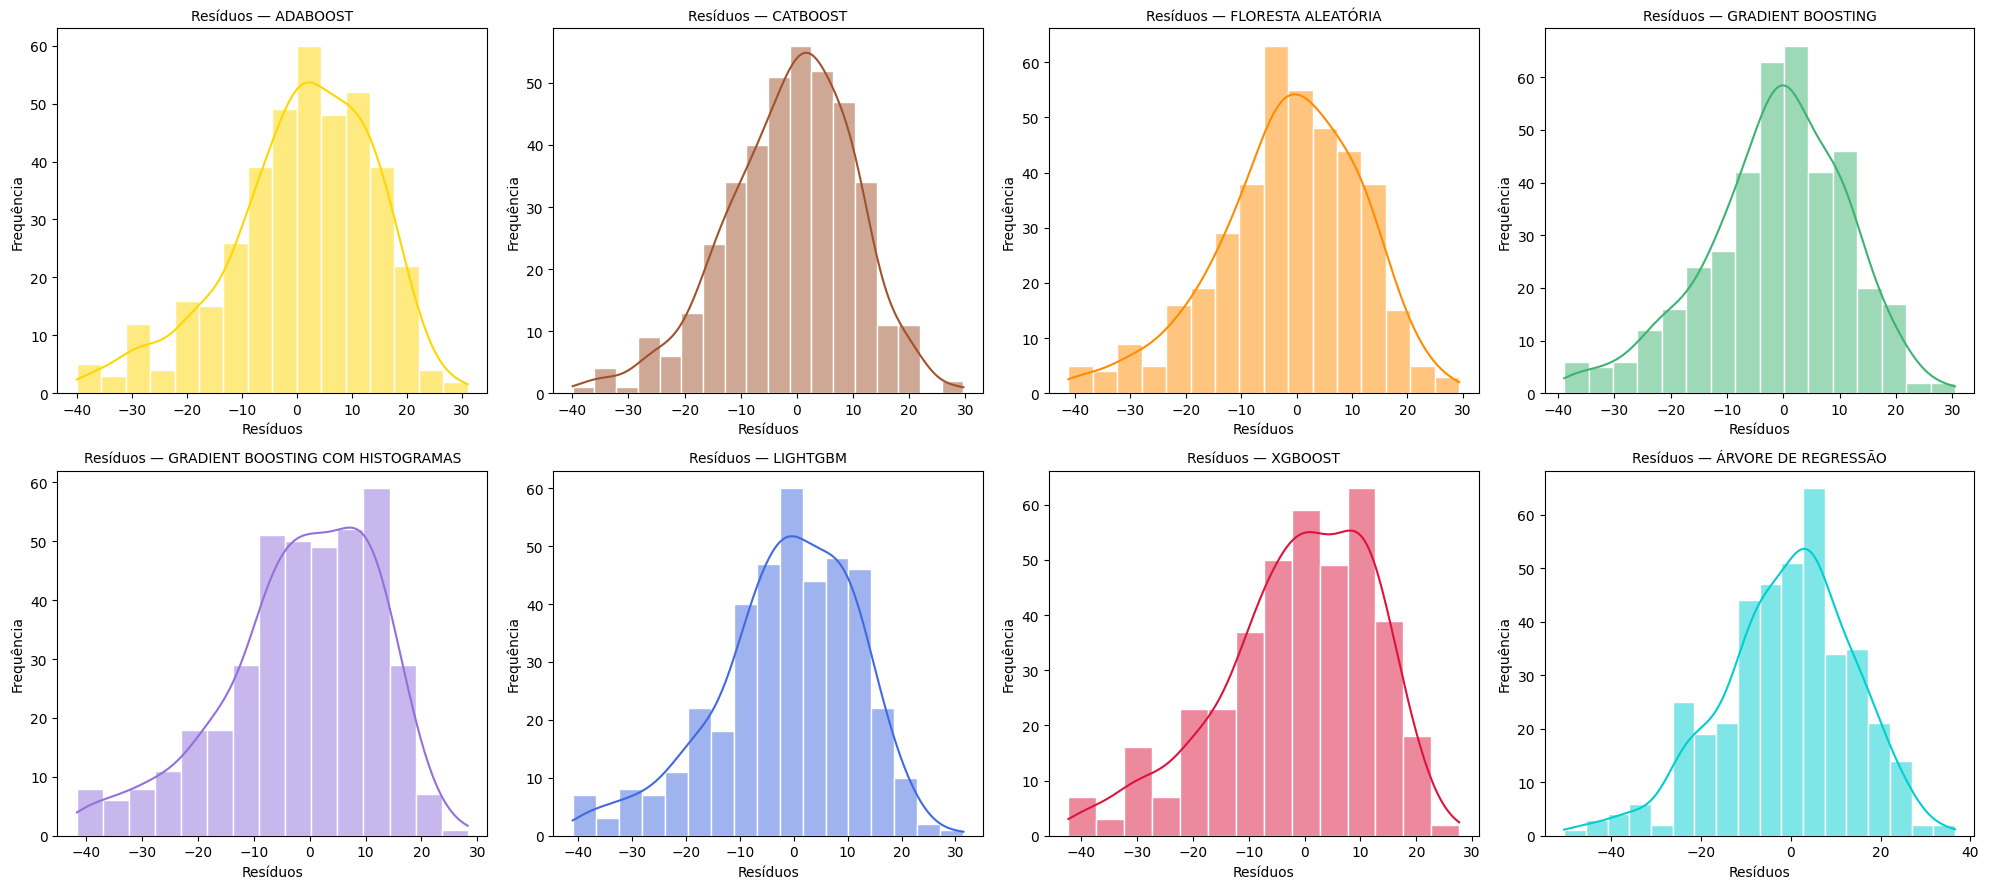

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 34 — Histograma dos resíduos, lado a lado
# ==============================================================================
nomes = list(residuos.keys())
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, nome in zip(axes.flatten(), nomes):
    sns.histplot(residuos[nome], color=CORES[nome], edgecolor="white", kde=True, ax=ax)
    ax.set_title(f"Resíduos — {nome}", fontsize=10)
    ax.set_xlabel("Resíduos")
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

# Foi construído um painel com um histograma dos resíduos por algoritmo (8 no total), permitindo comparar a forma
# e a dispersão da distribuição do erro entre os modelos.

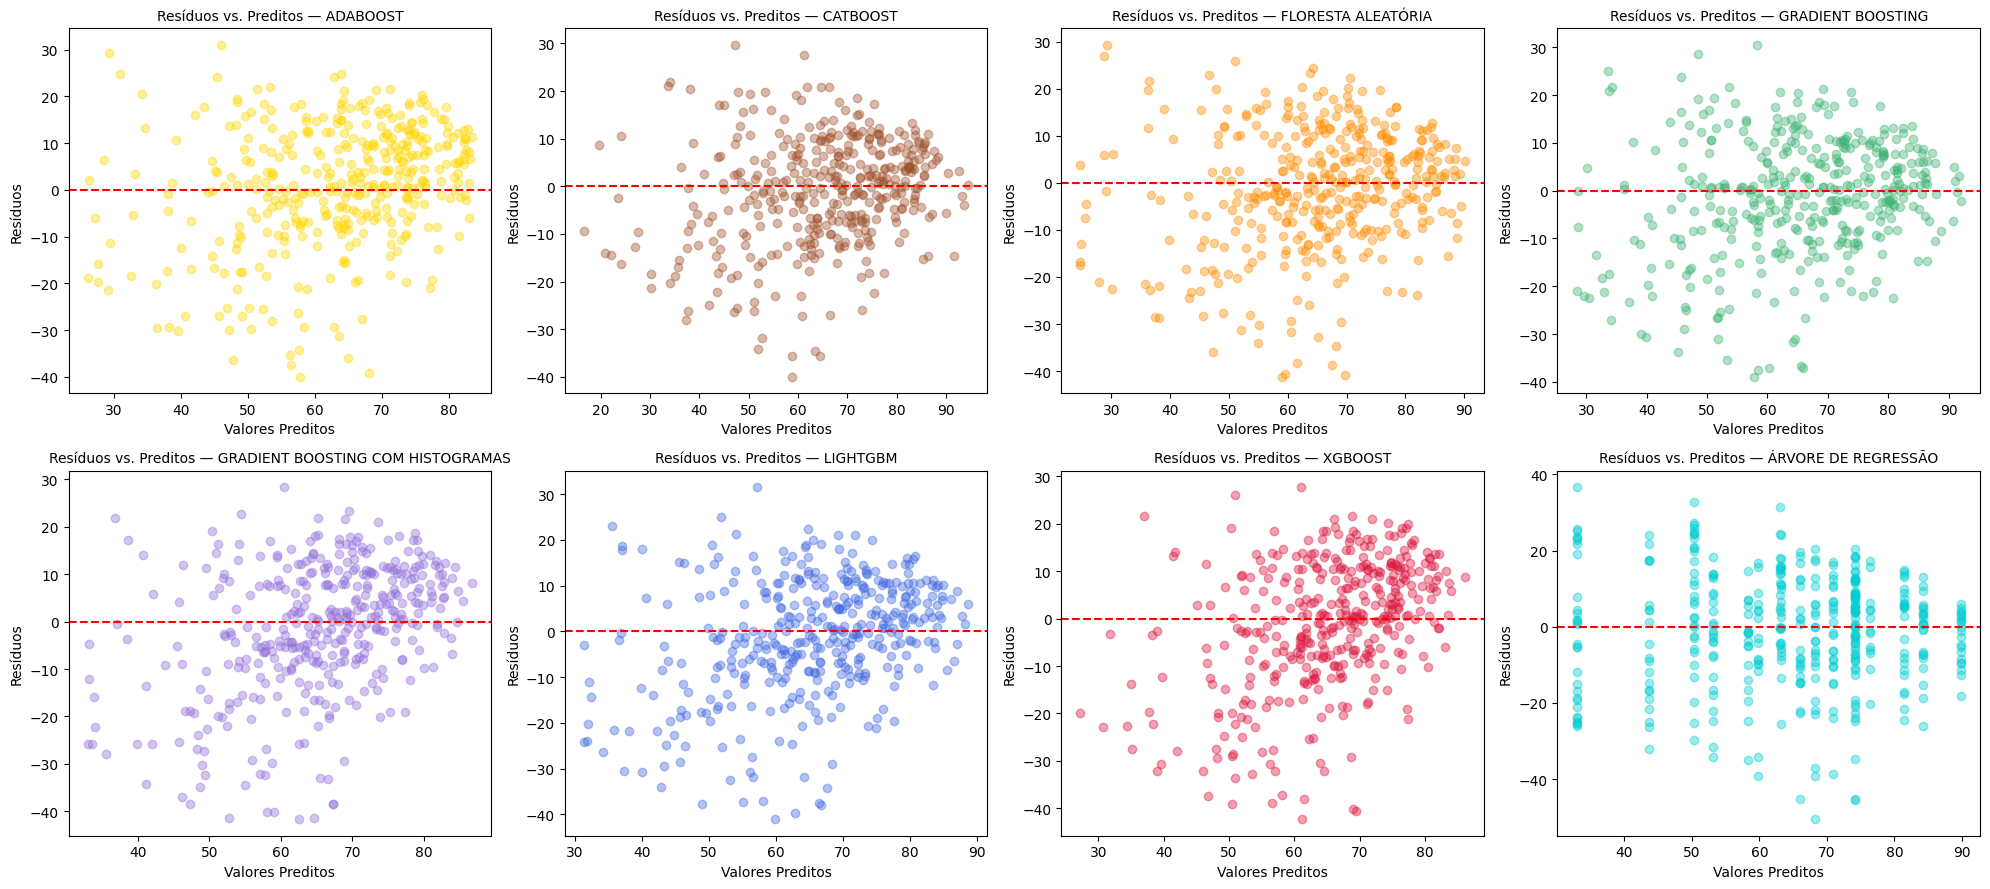

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 35 — Resíduos vs. valores preditos, lado a lado
# ==============================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, nome in zip(axes.flatten(), nomes):
    ax.scatter(predicoes_teste[nome], residuos[nome], color=CORES[nome], alpha=0.4)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"Resíduos vs. Preditos — {nome}", fontsize=10)
    ax.set_xlabel("Valores Preditos")
    ax.set_ylabel("Resíduos")
plt.tight_layout()
plt.show()

# Foi construído um painel com um gráfico de dispersão (resíduo vs. predito) por algoritmo, com uma linha de
# referência em zero, útil para identificar padrões (heterocedasticidade, viés) nos resíduos de cada modelo.

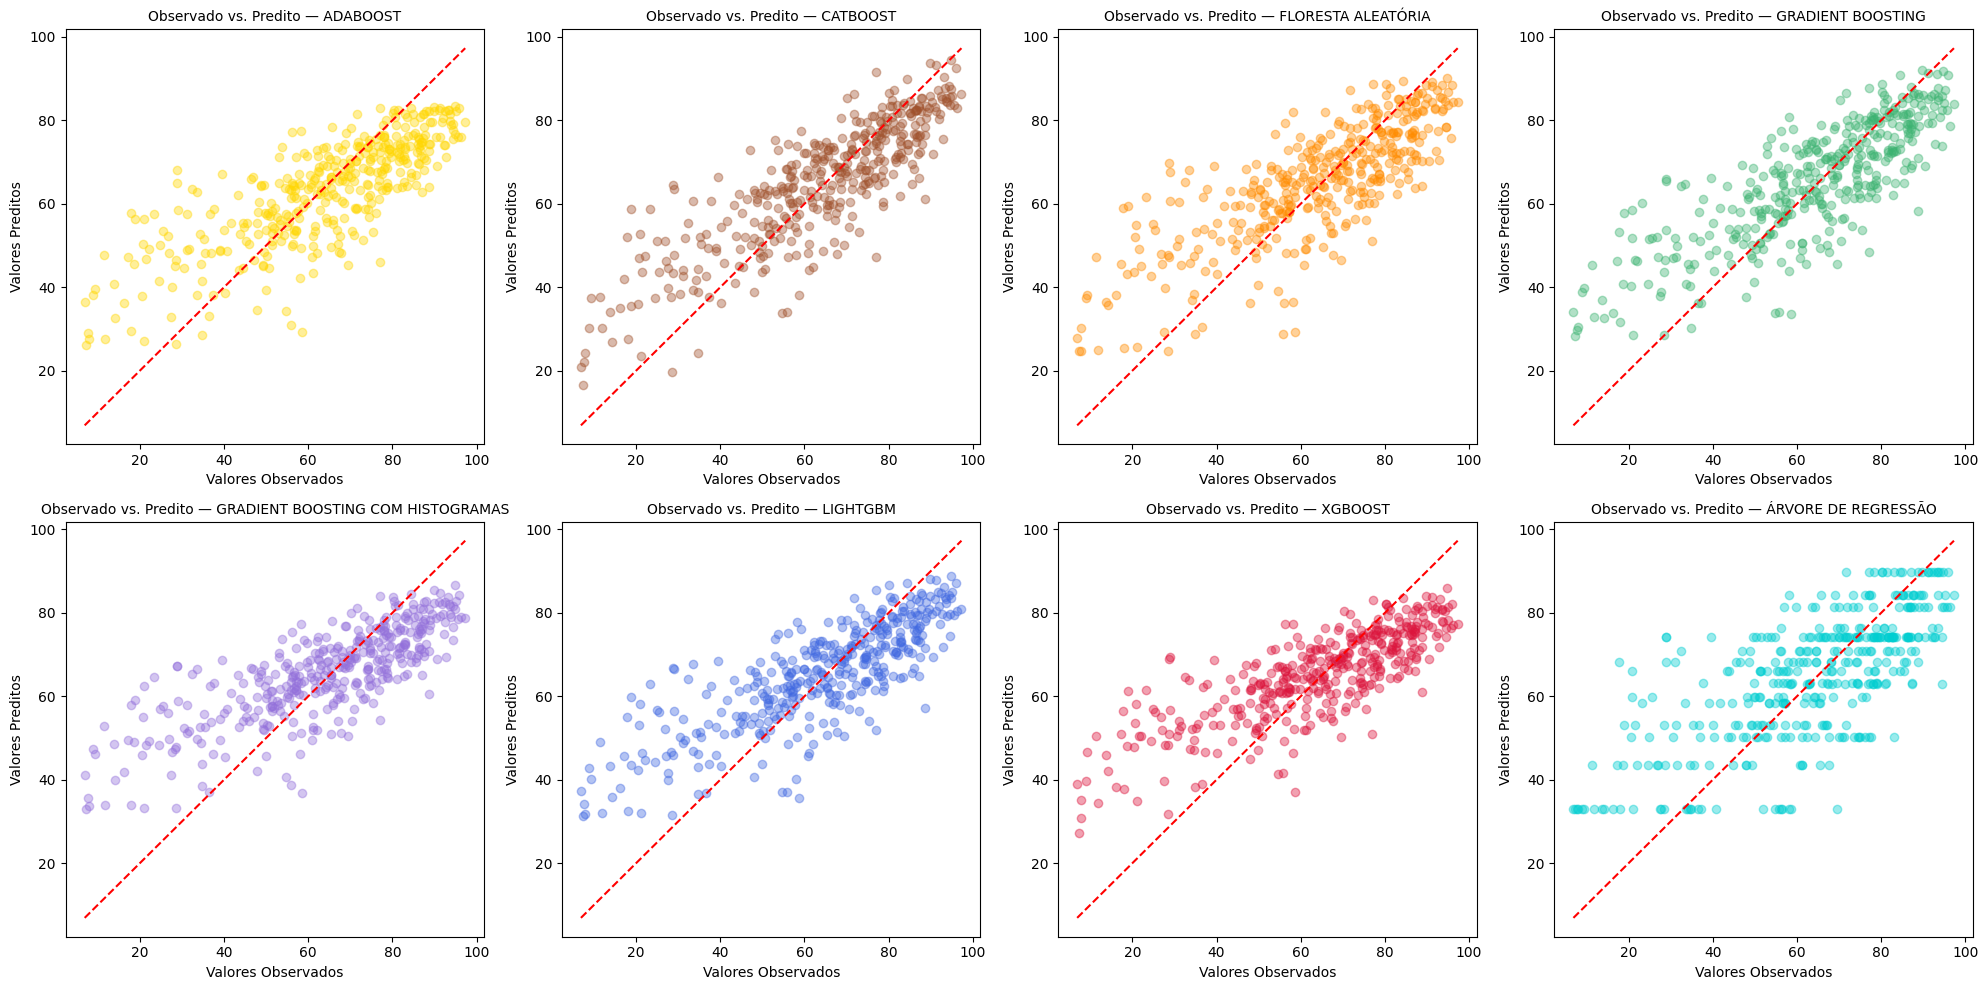

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 36 — Valores observados vs. valores preditos, lado a lado
# ==============================================================================
min_eixo = min(y_teste.min(), min(p.min() for p in predicoes_teste.values()))
max_eixo = max(y_teste.max(), max(p.max() for p in predicoes_teste.values()))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, nome in zip(axes.flatten(), nomes):
    ax.scatter(y_teste, predicoes_teste[nome], color=CORES[nome], alpha=0.4)
    ax.plot([min_eixo, max_eixo], [min_eixo, max_eixo], color='red', linestyle='--')
    ax.set_title(f"Observado vs. Predito — {nome}", fontsize=10)
    ax.set_xlabel("Valores Observados")
    ax.set_ylabel("Valores Preditos")
plt.tight_layout()
plt.show()

# Foi construído um painel com um gráfico de dispersão (observado vs. predito) por algoritmo, com a reta de 45°
# como referência de acerto perfeito, permitindo comparar visualmente a qualidade do ajuste dos 8 modelos.

### **Etapa 11: Interpretabilidade comparada — Importância das Variáveis**

*Três critérios de importância são comparados entre os 8 modelos finais: **redução de impureza** (nativo dos algoritmos baseados em árvore — não disponível para o Gradient Boosting com Histogramas, que não expõe `feature_importances_`), **permutação** (mede a queda de desempenho ao embaralhar cada variável) e **SHAP** (mede a contribuição marginal média de cada variável para a predição, com base na teoria dos jogos). Como o CatBoost usa variáveis categóricas em seu formato original (sem one-hot), suas linhas nas tabelas comparativas aparecem sob o nome original da variável (ex.: `CATEGORIA`), enquanto os demais algoritmos aparecem sob o nome das dummies (ex.: `CATEGORIA_Culinaria`); o pandas alinha automaticamente os índices, preenchendo com `NaN` onde a variável (ou dummy) não existe naquele modelo.*

#### *11.1. Importância por Redução de Impureza*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 37 — Cálculo da importância por redução de impureza
# ==============================================================================
importancias_impureza = {}
for nome, modelo in modelos_finais.items():
    if not hasattr(modelo, 'feature_importances_'):
        continue   # Gradient Boosting com Histogramas não expõe 'feature_importances_' (recomendação do sklearn é usar permutação)
    tipo_dado = algoritmos[nome][2]
    colunas = X_treino_tratada.columns if tipo_dado == 'tratada' else X_treino.columns
    importancias_impureza[nome] = pd.Series(modelo.feature_importances_, index=colunas)

importancias_impureza = pd.DataFrame(importancias_impureza)
importancias_impureza_ordenada = importancias_impureza.reindex(
    importancias_impureza.mean(axis=1).sort_values().index
)
importancias_impureza_ordenada

# Foi calculada a importância nativa por redução de impureza de cada variável, para os 7 modelos que expõem
# 'feature_importances_' (todos exceto o Gradient Boosting com Histogramas), organizada em um único data frame
# ordenado (ascendente) pela importância média entre os algoritmos.

,ADABOOST,CATBOOST,FLORESTA ALEATÓRIA,GRADIENT BOOSTING,LIGHTGBM,XGBOOST,ÁRVORE DE REGRESSÃO
trabalha_alem_estudar_sim,0.001,NaN,0.000,0.000,0.000,0.045,0.000
trabalha_alem_estudar,NaN,0.736,NaN,NaN,NaN,NaN,NaN
escolaridade_pais_mestrado-doutorado,0.000,NaN,0.000,0.000,5.000,0.013,0.000
turno,NaN,1.438,NaN,NaN,NaN,NaN,NaN
nro_irmaos,0.003,0.578,0.002,0.004,16.000,0.000,0.000
possui_transporte_proprio,NaN,4.076,NaN,NaN,NaN,NaN,NaN
escolaridade_pais_medio,0.004,NaN,0.004,0.007,30.000,0.045,0.000
tempo_deslocamento_min,0.003,0.597,0.006,0.006,38.000,0.019,0.000
acesso_internet_casa,NaN,6.083,NaN,NaN,NaN,NaN,NaN
escolaridade_pais_superior,0.010,NaN,0.002,0.011,38.000,0.042,0.000


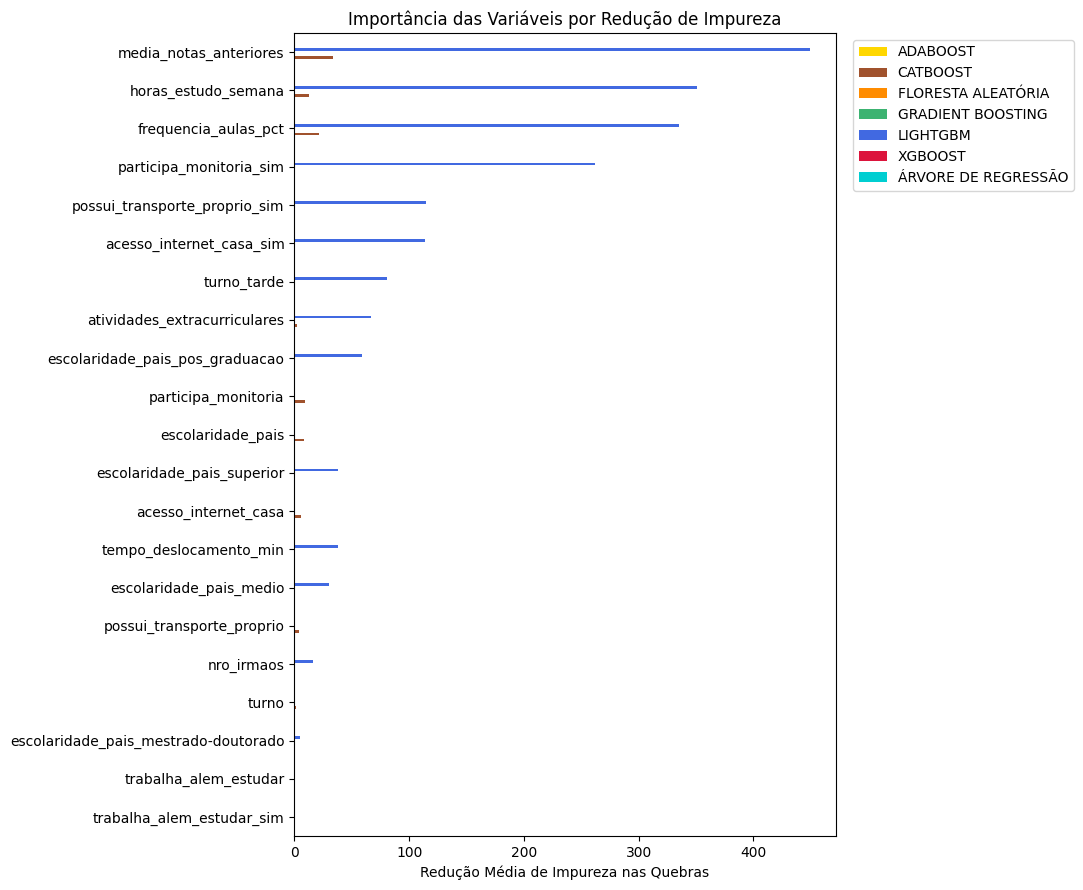

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 38 — Gráfico comparativo de importância por redução de impureza
# ==============================================================================
importancias_impureza_ordenada.plot.barh(
    figsize=(11, 9),
    color=[CORES[c] for c in importancias_impureza_ordenada.columns]
)
plt.title("Importância das Variáveis por Redução de Impureza")
plt.xlabel("Redução Média de Impureza nas Quebras")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Foi construído um gráfico de barras horizontais agrupadas (via 'plot.barh' do pandas), comparando a importância
# por redução de impureza de cada variável entre os algoritmos; como o data frame está ordenado de forma
# ascendente, as variáveis mais importantes ficam no topo do gráfico.

#### *11.2. Importância por Permutação*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 39 — Cálculo da importância por permutação
# ==============================================================================
importancias_permutacao = {}
for nome, modelo in modelos_finais.items():
    tipo_dado = algoritmos[nome][2]
    X_base = X_treino_tratada if tipo_dado == 'tratada' else X_treino
    resultado_perm = permutation_importance(modelo,
                                             X_base,
                                             y_treino,
                                             n_repeats=30,
                                             random_state=123,
                                             scoring='neg_root_mean_squared_error')
    importancias_permutacao[nome] = pd.Series(resultado_perm.importances_mean, index=X_base.columns)

importancias_permutacao = pd.DataFrame(importancias_permutacao)
importancias_permutacao_ordenada = importancias_permutacao.reindex(
    importancias_permutacao.mean(axis=1).sort_values().index
)
importancias_permutacao_ordenada

# Foi calculada a importância por permutação (30 repetições, medida como impacto no RMSE) de cada variável, para os
# 8 modelos finais (cada um em seu próprio espaço de variáveis), organizada em um único data frame ordenado pela
# importância média.

,ADABOOST,CATBOOST,FLORESTA ALEATÓRIA,GRADIENT BOOSTING,GRADIENT BOOSTING COM HISTOGRAMAS,LIGHTGBM,XGBOOST,ÁRVORE DE REGRESSÃO
escolaridade_pais_mestrado-doutorado,0.001,NaN,0.000,0.000,0.004,0.012,0.005,0.000
trabalha_alem_estudar_sim,0.002,NaN,0.000,0.000,0.000,0.000,0.073,0.000
nro_irmaos,0.007,0.075,0.019,0.053,0.000,0.021,0.000,0.000
tempo_deslocamento_min,0.014,0.073,0.061,0.066,0.007,0.019,0.009,0.000
escolaridade_pais_medio,0.027,NaN,0.059,0.064,0.064,0.057,0.035,0.000
turno_tarde,0.035,NaN,0.078,0.226,0.043,0.139,0.025,0.000
escolaridade_pais_superior,0.059,NaN,0.027,0.190,0.097,0.201,0.020,0.000
trabalha_alem_estudar,NaN,0.087,NaN,NaN,NaN,NaN,NaN,NaN
atividades_extracurriculares,0.071,0.319,0.103,0.169,0.041,0.098,0.019,0.000
turno,NaN,0.199,NaN,NaN,NaN,NaN,NaN,NaN


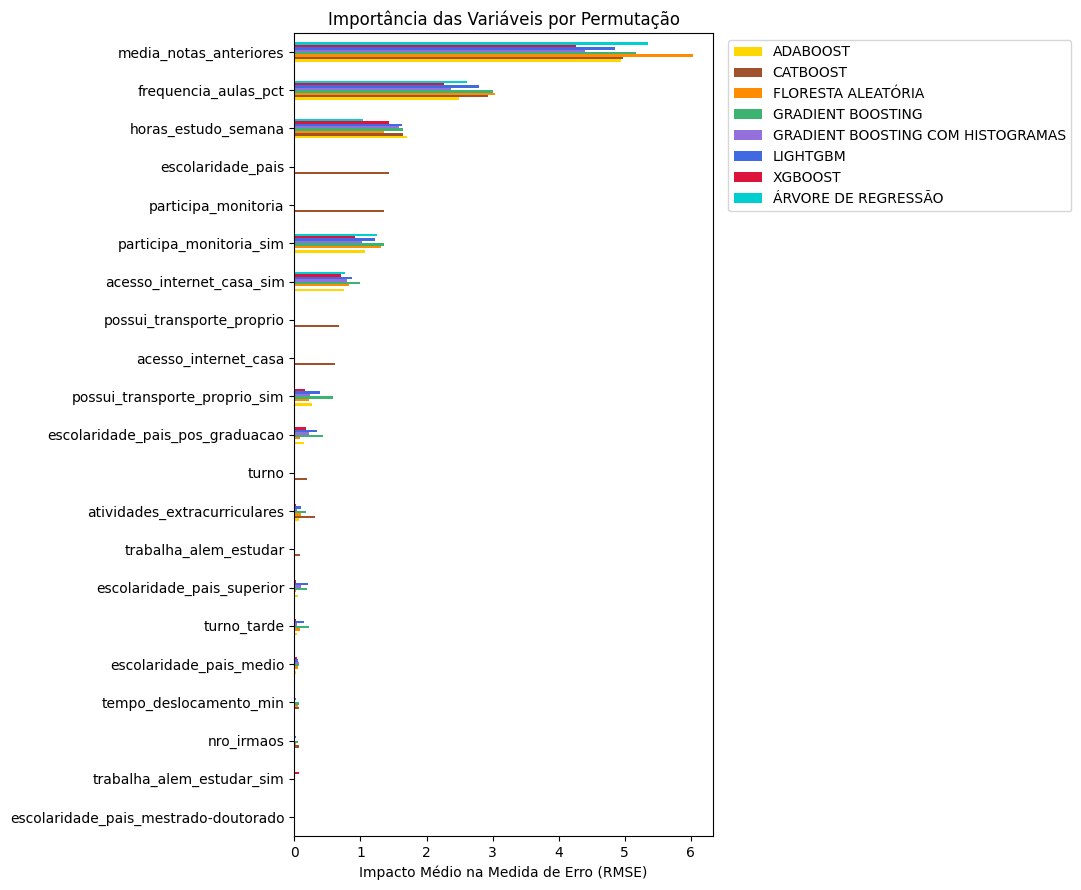

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 40 — Gráfico comparativo de importância por permutação
# ==============================================================================
importancias_permutacao_ordenada.plot.barh(
    figsize=(11, 9),
    color=[CORES[c] for c in importancias_permutacao_ordenada.columns]
)
plt.title("Importância das Variáveis por Permutação")
plt.xlabel("Impacto Médio na Medida de Erro (RMSE)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Foi construído um gráfico de barras horizontais agrupadas comparando a importância por permutação de cada
# variável entre os 8 algoritmos.

#### *11.3. Importância por Valores SHAP*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 41 — Cálculo dos valores SHAP
# ==============================================================================
valores_shap = {}
X_base_shap = {}   # Guarda, por modelo, o conjunto de dados usado no cálculo (para os gráficos seguintes)

for nome, modelo in modelos_finais.items():
    print(f"Calculando SHAP para: {nome}")
    tipo_dado = algoritmos[nome][2]

    if nome == 'ADABOOST':
        # A implementação exata (TreeExplainer) não é direta para o AdaBoost; usa-se um método
        # mais oneroso (baseado na função de predição), em uma subamostra pequena de observações
        X_amostra = shap.sample(X_treino_tratada, 100, random_state=123)
        explainer = shap.Explainer(modelo.predict, X_amostra)
        valores_shap[nome] = explainer(X_amostra)
        X_base_shap[nome] = X_amostra

    elif tipo_dado == 'raw':
        # CatBoost: dados brutos, com as variáveis categóricas em seu formato original
        X_base = X_treino
        explainer = shap.TreeExplainer(modelo)
        valores_shap[nome] = explainer(X_base, check_additivity=False)
        X_base_shap[nome] = X_base

    else:
        # Demais algoritmos baseados em árvore: TreeExplainer no espaço das dummies
        X_base = X_treino_tratada
        explainer = shap.TreeExplainer(modelo)
        valores_shap[nome] = explainer(X_base, check_additivity=False)
        X_base_shap[nome] = X_base

# Foram calculados os valores SHAP dos 8 modelos finais, com tratamento específico para o
# AdaBoost (subamostra de 100 observações, pois não tem suporte direto a TreeExplainer) e para
# o CatBoost (dados brutos). O 'check_additivity=False' desliga apenas a conferência numérica
# de que a soma dos SHAP reproduz exatamente a predição — verificação que dispara falsos
# alertas por tolerância de arredondamento em modelos com muitas árvores, sem afetar os valores
# calculados. Nenhum erro é silenciado aqui: se algum modelo falhar, a execução para no ponto
# do problema, em vez de deixar o data frame de importâncias incompleto nos blocos seguintes.

Calculando SHAP para: ADABOOST


PermutationExplainer explainer: 101it [02:07,  1.29s/it]


Calculando SHAP para: CATBOOST
Calculando SHAP para: FLORESTA ALEATÓRIA
Calculando SHAP para: GRADIENT BOOSTING
Calculando SHAP para: GRADIENT BOOSTING COM HISTOGRAMAS
Calculando SHAP para: LIGHTGBM
Calculando SHAP para: XGBOOST
Calculando SHAP para: ÁRVORE DE REGRESSÃO


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 42 — Tabela comparativa de importância por SHAP (valor absoluto médio)
# ==============================================================================
importancias_shap = pd.DataFrame({
    nome: pd.Series(np.abs(sv.values).mean(axis=0), index=X_base_shap[nome].columns)
    for nome, sv in valores_shap.items()
})
importancias_shap_ordenada = importancias_shap.reindex(
    importancias_shap.mean(axis=1).sort_values().index
)
importancias_shap_ordenada

# Foi calculado o valor absoluto médio de SHAP de cada variável, para os 8 modelos finais, e organizado em um único
# data frame ordenado pela importância média — a mesma métrica usada no gráfico de barras nativo do SHAP.

,ADABOOST,CATBOOST,FLORESTA ALEATÓRIA,GRADIENT BOOSTING,GRADIENT BOOSTING COM HISTOGRAMAS,LIGHTGBM,XGBOOST,ÁRVORE DE REGRESSÃO
escolaridade_pais_mestrado-doutorado,0.000,NaN,0.000,0.000,0.015,0.042,0.006,0.000
trabalha_alem_estudar_sim,0.003,NaN,0.000,0.000,0.000,0.000,0.108,0.000
nro_irmaos,0.039,0.379,0.073,0.259,0.000,0.072,0.000,0.000
tempo_deslocamento_min,0.057,0.289,0.202,0.390,0.041,0.108,0.035,0.000
trabalha_alem_estudar,NaN,0.185,NaN,NaN,NaN,NaN,NaN,NaN
escolaridade_pais_medio,0.168,NaN,0.215,0.372,0.248,0.247,0.165,0.000
escolaridade_pais_superior,0.188,NaN,0.117,0.731,0.332,0.594,0.078,0.000
turno_tarde,0.186,NaN,0.326,0.964,0.171,0.519,0.150,0.000
atividades_extracurriculares,0.290,1.241,0.342,0.711,0.173,0.348,0.062,0.000
escolaridade_pais_pos_graduacao,0.401,NaN,0.232,1.136,0.560,0.817,0.560,0.000


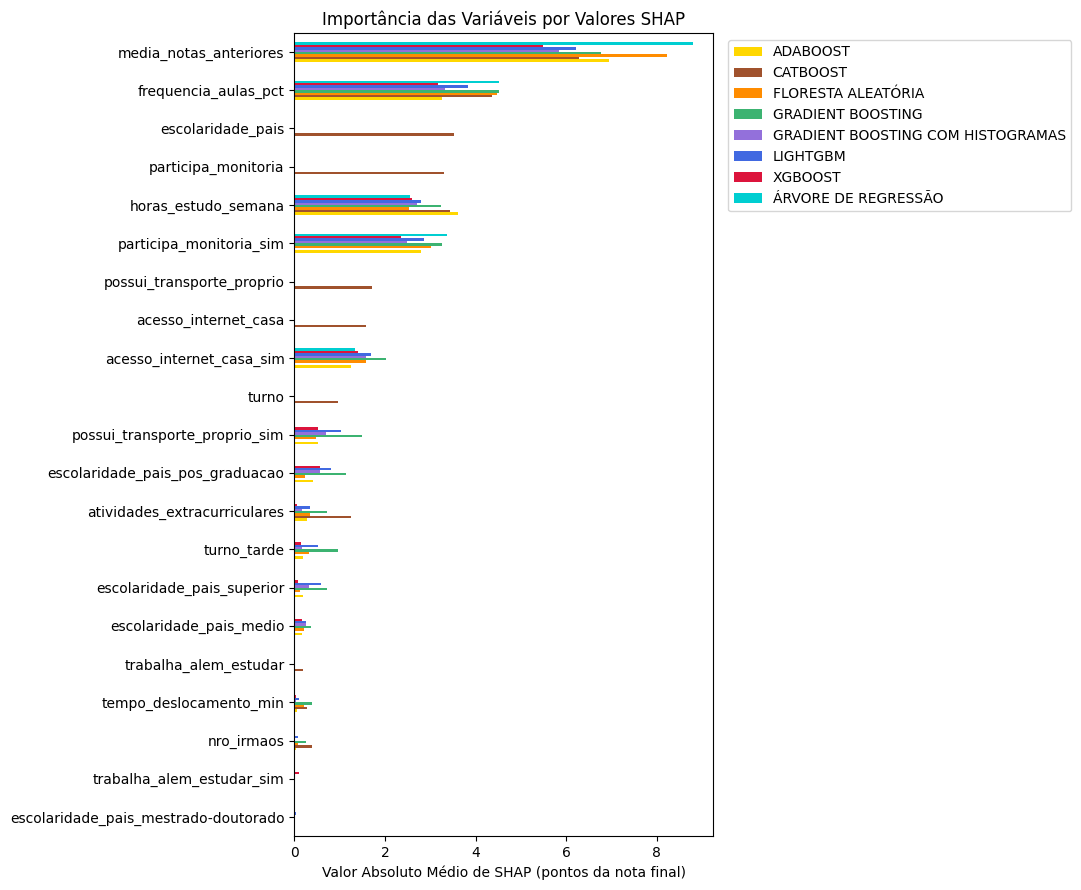

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 43 — Gráfico comparativo de importância por SHAP
# ==============================================================================
importancias_shap_ordenada.plot.barh(
    figsize=(11, 9),
    color=[CORES[c] for c in importancias_shap_ordenada.columns]
)
plt.title("Importância das Variáveis por Valores SHAP")
plt.xlabel("Valor Absoluto Médio de SHAP (pontos da nota final)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Foi construído um gráfico de barras horizontais agrupadas comparando a importância por valores SHAP de cada
# variável entre os 8 algoritmos.

*Gráficos de direção do impacto (beeswarm), um por modelo — gerados com o gráfico nativo do SHAP (`shap.summary_plot`), assim como nos notebooks originais; não são comparáveis lado a lado em um único gráfico, pois cada ponto representa uma observação.*

--- ADABOOST ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


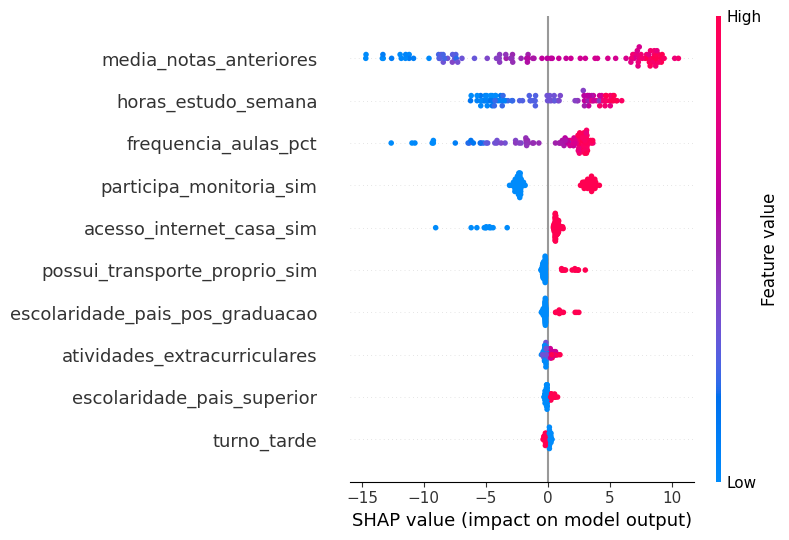

--- CATBOOST ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


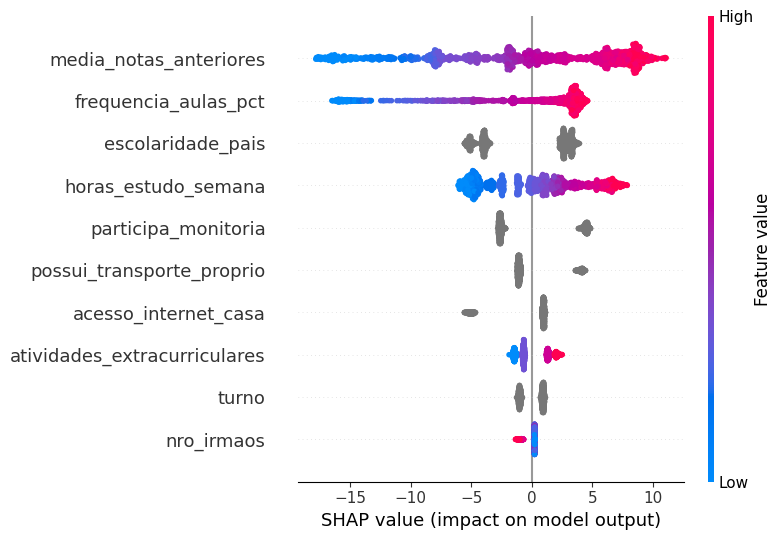

--- FLORESTA ALEATÓRIA ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


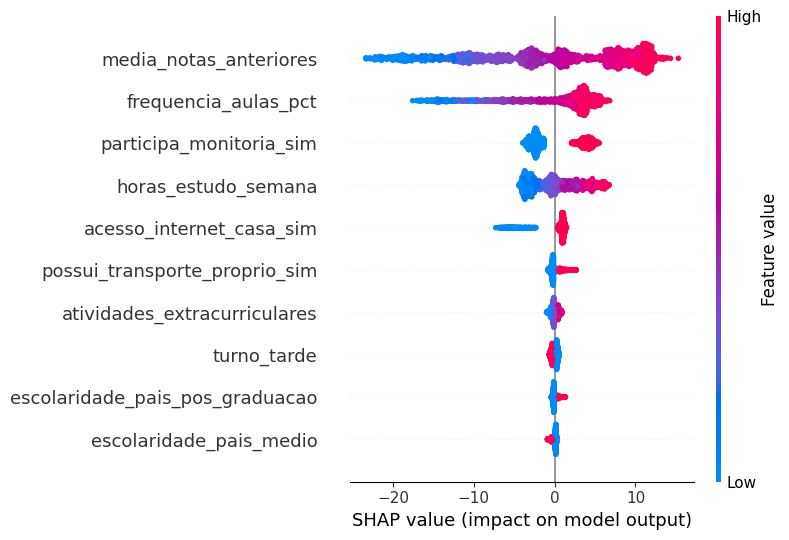

--- GRADIENT BOOSTING ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


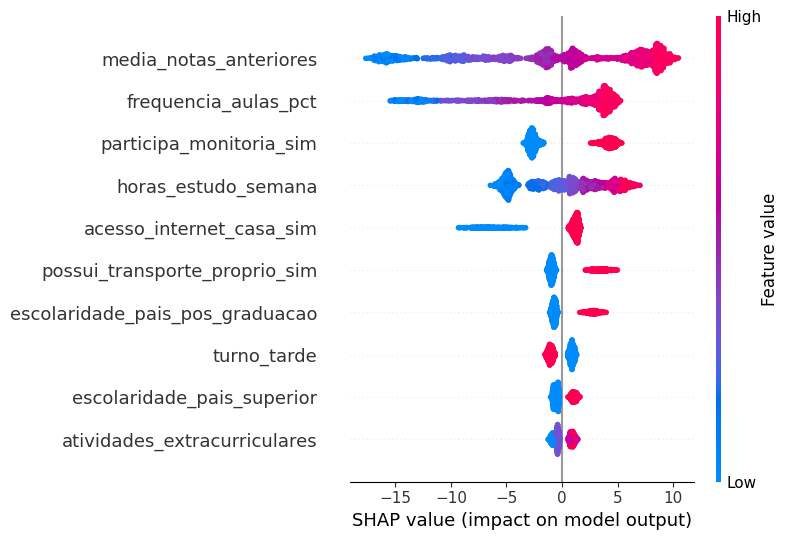

--- GRADIENT BOOSTING COM HISTOGRAMAS ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


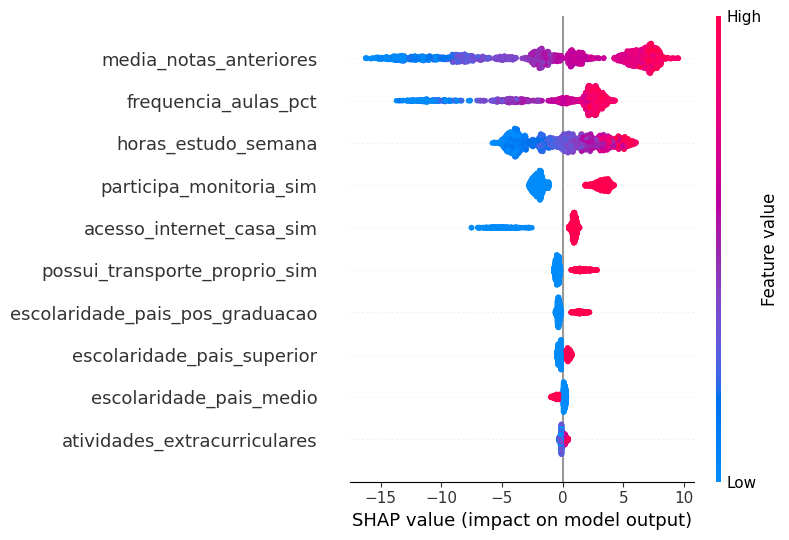

--- LIGHTGBM ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


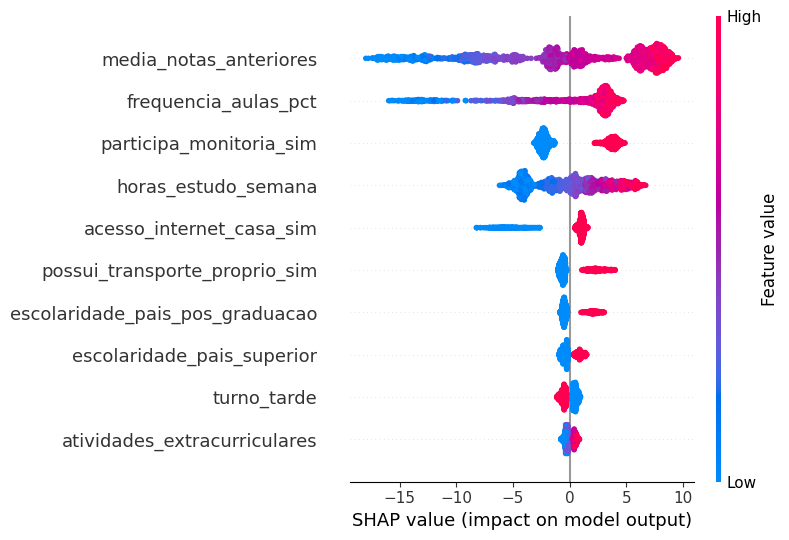

--- XGBOOST ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


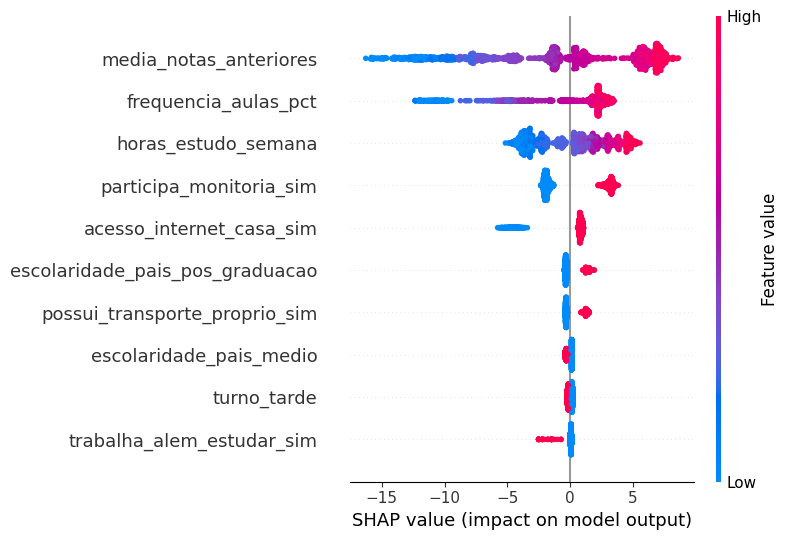

--- ÁRVORE DE REGRESSÃO ---


/tmp/ipykernel_596/3519428469.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_base_shap[nome], max_display=10)


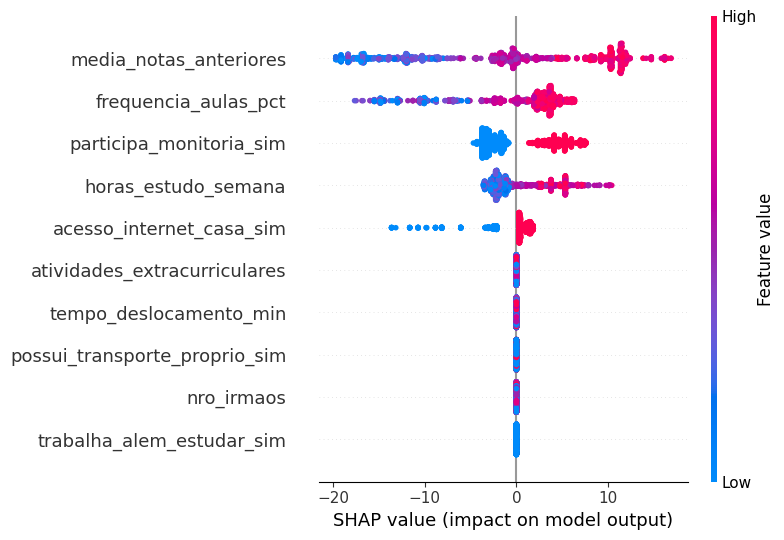

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 44 — Gráficos beeswarm de SHAP (um por modelo)
# ==============================================================================
for nome, sv in valores_shap.items():
    print(f"--- {nome} ---")
    shap.summary_plot(sv, X_base_shap[nome], max_display=10)

# Foi gerado, para cada um dos 8 modelos, o gráfico beeswarm nativo do SHAP ('shap.summary_plot'), mostrando a
# direção e a magnitude do impacto de cada variável na predição, observação a observação.

#### *11.4. Ranking consolidado dos três critérios, por modelo*

*Compara, para cada modelo, a posição (rank) de cada variável nos três critérios — útil para identificar variáveis cuja importância é inflada pela redução de impureza (comum em variáveis qualitativas com muitas categorias) mas não confirmada por permutação/SHAP. Ranking dentro do próprio espaço de variáveis de cada modelo (dummies para 7 algoritmos, variáveis originais para o CatBoost); a coluna 'Impureza' fica ausente para o Gradient Boosting com Histogramas, que não expõe essa métrica.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 45 — Ranking consolidado de importância por modelo
# ==============================================================================
for nome in modelos_finais:
    criterios = {
        "Permutação": importancias_permutacao[nome].rank(ascending=False),
        "SHAP": importancias_shap[nome].rank(ascending=False),
    }
    if nome in importancias_impureza.columns:
        criterios["Impureza"] = importancias_impureza[nome].dropna().rank(ascending=False)

    ranking = pd.DataFrame(criterios).sort_values(
        "Impureza" if "Impureza" in criterios else "SHAP"
    )
    print(f"--- Ranking de importância das variáveis — {nome} ---")
    display(ranking)

# Foi montada, para cada um dos 8 modelos, uma tabela com o ranking de cada variável nos critérios de importância
# disponíveis, permitindo verificar se impureza, permutação e SHAP concordam sobre quais variáveis mais importam.

--- Ranking de importância das variáveis — ADABOOST ---


,Permutação,SHAP,Impureza
media_notas_anteriores,1.000,1.000,1.000
frequencia_aulas_pct,2.000,3.000,2.000
horas_estudo_semana,3.000,2.000,3.000
participa_monitoria_sim,4.000,4.000,4.000
acesso_internet_casa_sim,5.000,5.000,5.000
possui_transporte_proprio_sim,6.000,6.000,6.000
escolaridade_pais_pos_graduacao,7.000,7.000,7.000
atividades_extracurriculares,8.000,8.000,8.000
escolaridade_pais_superior,9.000,9.000,9.000
turno_tarde,10.000,10.000,10.000


--- Ranking de importância das variáveis — CATBOOST ---


,Permutação,SHAP,Impureza
media_notas_anteriores,1.000,1.000,1.000
frequencia_aulas_pct,2.000,2.000,2.000
horas_estudo_semana,3.000,4.000,3.000
participa_monitoria,5.000,5.000,4.000
escolaridade_pais,4.000,3.000,5.000
acesso_internet_casa,7.000,7.000,6.000
possui_transporte_proprio,6.000,6.000,7.000
atividades_extracurriculares,8.000,8.000,8.000
turno,9.000,9.000,9.000
trabalha_alem_estudar,10.000,12.000,10.000


--- Ranking de importância das variáveis — FLORESTA ALEATÓRIA ---


...

,Permutação,SHAP,Impureza
media_notas_anteriores,1.000,1.000,1.000
horas_estudo_semana,3.000,4.000,2.000
frequencia_aulas_pct,2.000,2.000,3.000
participa_monitoria_sim,4.000,3.000,4.000
possui_transporte_proprio_sim,6.000,6.000,5.000
acesso_internet_casa_sim,5.000,5.000,6.000
turno_tarde,9.000,9.000,7.000
atividades_extracurriculares,10.000,10.000,8.000
escolaridade_pais_pos_graduacao,7.000,7.000,9.000
tempo_deslocamento_min,13.000,12.000,10.500


--- Ranking de importância das variáveis — XGBOOST ---


,Permutação,SHAP,Impureza
media_notas_anteriores,1.000,1.000,1.000
frequencia_aulas_pct,2.000,2.000,2.000
horas_estudo_semana,3.000,3.000,3.000
participa_monitoria_sim,4.000,4.000,4.000
acesso_internet_casa_sim,5.000,5.000,5.000
possui_transporte_proprio_sim,7.000,7.000,6.000
escolaridade_pais_pos_graduacao,6.000,6.000,7.000
trabalha_alem_estudar_sim,8.000,10.000,8.000
escolaridade_pais_medio,9.000,8.000,9.000
escolaridade_pais_superior,11.000,11.000,10.000


--- Ranking de importância das variáveis — ÁRVORE DE REGRESSÃO ---


,Permutação,SHAP,Impureza
media_notas_anteriores,1.000,1.000,1.000
frequencia_aulas_pct,2.000,2.000,2.000
participa_monitoria_sim,3.000,3.000,3.000
horas_estudo_semana,4.000,4.000,4.000
acesso_internet_casa_sim,5.000,5.000,5.000
escolaridade_pais_medio,10.500,10.500,10.500
escolaridade_pais_mestrado-doutorado,10.500,10.500,10.500
atividades_extracurriculares,10.500,10.500,10.500
escolaridade_pais_pos_graduacao,10.500,10.500,10.500
escolaridade_pais_superior,10.500,10.500,10.500


### **Etapa 12: Refinamento do algoritmo campeão (CatBoost) por busca em grade**

*A Etapa 5 varreu o espaço de hiperparâmetros de forma **ampla e aleatória** (`RandomizedSearchCV`, 100 combinações por algoritmo). Agora que o CatBoost se mostrou o algoritmo campeão, esta etapa faz o caminho inverso: uma busca **exaustiva e local** (`GridSearchCV`) em uma grade construída **ao redor dos hiperparâmetros do modelo campeão já escolhido na Etapa 7** — ou seja, refina o que já foi encontrado, em vez de recomeçar do zero.*

*Três decisões metodológicas sustentam esta etapa:*

*1. **A âncora é o modelo escolhido na Etapa 7** (`modelos_escolhidos`), que já passou pelo filtro de superajuste da Etapa 6 — e não o modelo de menor erro entre todos os testados, que pode ter sido reprovado naquele filtro;*

*2. **A mesma validação cruzada** (`kf`, 5 folds, `random_state=123`) e a **mesma métrica** (`neg_root_mean_squared_error`) da Etapa 5 são reutilizadas, o que torna os erros das duas buscas diretamente comparáveis;*

*3. **O conjunto de teste externo não participa da otimização.** Ele é usado apenas para medir o erro de cada combinação (como já era feito na Etapa 5) e para a avaliação final da Etapa 13.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 46 — Recuperação do modelo campeão (âncora da grade)
# ==============================================================================
# Algoritmo campeão da comparação (Etapas 6 e 9). Altere aqui caso outro algoritmo
# se mostre superior em uma nova execução.
NOME_ALGORITMO_CAMPEAO = 'CATBOOST'

# Linha do modelo campeão na tabela da Etapa 7 — já filtrada pelo critério de
# superajuste da Etapa 6 (variação de erro treino -> teste interno/externo < 10%)
linha_ancora = modelos_escolhidos.loc[NOME_ALGORITMO_CAMPEAO]

hiperparametros_ancora = dict(linha_ancora['hiperparametros'])
classe_campea, _, tipo_dado_campeao = algoritmos[NOME_ALGORITMO_CAMPEAO]

# Conjuntos de dados e parâmetros de 'fit' do algoritmo campeão (mesma lógica do Bloco 16)
if tipo_dado_campeao == 'tratada':
    X_treino_campeao, X_teste_campeao = X_treino_tratada, X_teste_tratada
    fit_kwargs_campeao = {}
else:  # 'raw' — CatBoost, que trata variáveis categóricas nativamente
    X_treino_campeao, X_teste_campeao = X_treino, X_teste
    fit_kwargs_campeao = {'cat_features': lista_X_quali}

# Erros do modelo âncora, para servirem de referência na comparação da Etapa 13
rmse_treino_ancora = float(linha_ancora['media_erro_treino'])
rmse_cv_ancora = float(linha_ancora['media_erro_teste_interno'])
rmse_teste_ancora = float(linha_ancora['erro_teste_externo'])

print("=" * 78)
print(f"MODELO ÂNCORA — MELHOR {NOME_ALGORITMO_CAMPEAO} DA BUSCA ALEATÓRIA (ETAPA 7)")
print("=" * 78)
print(f"\nIdentificação: {linha_ancora['num_modelo']}")
print(f"Erro médio de treino (RMSE):        {rmse_treino_ancora:.4f}")
print(f"Erro médio de teste interno (RMSE): {rmse_cv_ancora:.4f}")
print(f"Erro de teste externo (RMSE):       {rmse_teste_ancora:.4f}")
print("\nHiperparâmetros:")
for parametro, valor in hiperparametros_ancora.items():
    print(f"  {parametro}: {valor}")

# Foi recuperado o modelo campeão escolhido na Etapa 7 (o mesmo já reajustado no Bloco 24 e
# avaliado nas Etapas 9 a 11), junto com seus três erros de referência e os conjuntos de dados
# apropriados ao algoritmo. É em torno destes hiperparâmetros que a grade será construída.

MODELO ÂNCORA — MELHOR CATBOOST DA BUSCA ALEATÓRIA (ETAPA 7)

Identificação: Modelo 777
Erro médio de treino (RMSE):        10.7053
Erro médio de teste interno (RMSE): 11.3131
Erro de teste externo (RMSE):       11.4107

Hiperparâmetros:
  depth: 3
  iterations: 193
  l2_leaf_reg: 0.17893837775831142
  learning_rate: 0.027280978122794227
  subsample: 0.7342175494157145


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 47 — Funções auxiliares para construir a grade em torno da âncora
# ==============================================================================
# Cada função gera (2 * n_lados + 1) valores centrados no valor da âncora, respeitando
# limites mínimo e máximo. Como o valor central é sempre o próprio valor da âncora, a
# grade contém a configuração campeã da Etapa 5 — garantindo que a busca em grade nunca
# possa piorar o erro de validação cruzada em relação ao ponto de partida.

def grade_inteira(valor, passo, n_lados=1, minimo=None, maximo=None):
    """Valores inteiros equidistantes ao redor da âncora (ex.: 3 -> [1, 2, 3, 4, 5])."""
    valor = int(round(float(valor)))
    valores = [valor + k * passo for k in range(-n_lados, n_lados + 1)]
    if minimo is not None:
        valores = [max(int(minimo), v) for v in valores]
    if maximo is not None:
        valores = [min(int(maximo), v) for v in valores]
    return sorted(set(int(v) for v in valores))


def grade_aditiva(valor, passo, n_lados=1, minimo=None, maximo=None, casas=6):
    """Valores contínuos somados/subtraídos da âncora (ex.: 0.73 -> [0.68, 0.73, 0.78])."""
    valor = float(valor)
    valores = [valor + k * passo for k in range(-n_lados, n_lados + 1)]
    if minimo is not None:
        valores = [max(float(minimo), v) for v in valores]
    if maximo is not None:
        valores = [min(float(maximo), v) for v in valores]
    return sorted(set(round(v, casas) for v in valores))


def grade_multiplicativa(valor, fator, n_lados=1, minimo=None, maximo=None, casas=8):
    """Valores proporcionais à âncora (ex.: fator 0.25 -> [-25%, valor, +25%])."""
    valor = float(valor)
    valores = [valor * (1 + k * fator) for k in range(-n_lados, n_lados + 1)]
    if minimo is not None:
        valores = [max(float(minimo), v) for v in valores]
    if maximo is not None:
        valores = [min(float(maximo), v) for v in valores]
    return sorted(set(round(v, casas) for v in valores))

# Foram definidas três funções auxiliares para gerar a vizinhança de cada hiperparâmetro:
# 'grade_inteira' para parâmetros discretos (profundidade, nº de árvores), 'grade_aditiva'
# para proporções (subamostragem) e 'grade_multiplicativa' para parâmetros em escala
# logarítmica (taxa de aprendizado, penalização L2). Valores repetidos após o corte pelos
# limites são eliminados automaticamente pelo 'set'.

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 48 — Definição da grade refinada de hiperparâmetros
# ==============================================================================
param_grid_catboost = {

    # Profundidade: 2 valores para cada lado da âncora (ex.: âncora 3 -> 1, 2, 3, 4, 5)
    'depth': grade_inteira(hiperparametros_ancora['depth'],
                           passo=1, n_lados=2, minimo=1, maximo=10),

    # Qtde. de árvores: 1 valor para cada lado, com passo de 20 árvores
    'iterations': grade_inteira(hiperparametros_ancora['iterations'],
                                passo=20, n_lados=1, minimo=10, maximo=500),

    # Taxa de aprendizado: 25% abaixo, valor da âncora e 25% acima
    'learning_rate': grade_multiplicativa(hiperparametros_ancora['learning_rate'],
                                          fator=0.25, n_lados=1, minimo=1e-4, maximo=1.0),

    # Penalização Ridge (L2): 30% abaixo, valor da âncora e 30% acima
    'l2_leaf_reg': grade_multiplicativa(hiperparametros_ancora['l2_leaf_reg'],
                                        fator=0.30, n_lados=1, minimo=1e-5, maximo=100),

    # Subamostragem: 5 pontos percentuais abaixo, valor da âncora e 5 acima
    'subsample': grade_aditiva(hiperparametros_ancora['subsample'],
                               passo=0.05, n_lados=1, minimo=0.5, maximo=1.0),
}

qtd_combinacoes = int(np.prod([len(valores) for valores in param_grid_catboost.values()]))

# Conferência: a configuração da âncora precisa estar contida na grade
ancora_na_grade = all(
    np.any(np.isclose(np.array(valores, dtype=float),
                      float(hiperparametros_ancora[parametro]),
                      rtol=1e-3))
    for parametro, valores in param_grid_catboost.items()
)

print("=" * 78)
print("GRADE REFINADA DE HIPERPARÂMETROS")
print("=" * 78)
for parametro, valores in param_grid_catboost.items():
    print(f"\n{parametro} (âncora = {hiperparametros_ancora[parametro]}):")
    print(f"  {valores}")

print(f"\nCombinações na grade: {qtd_combinacoes}")
print(f"Ajustes na validação cruzada: {qtd_combinacoes} x {kf.get_n_splits()} = "
      f"{qtd_combinacoes * kf.get_n_splits()}")
print(f"Ajustes adicionais para o teste externo: {qtd_combinacoes}")
print(f"\nConfiguração da âncora contida na grade: {'sim' if ancora_na_grade else 'NÃO'}")

# Foi construída a grade refinada em torno dos hiperparâmetros do modelo âncora e conferido
# que a própria configuração da âncora pertence à grade. O total de combinações é impresso
# antes da execução — se o tempo estimado for alto, reduza 'n_lados' ou remova algum
# hiperparâmetro da grade (o CatBoost usará, nesse caso, o valor padrão da biblioteca).

GRADE REFINADA DE HIPERPARÂMETROS

depth (âncora = 3):
  [1, 2, 3, 4, 5]

iterations (âncora = 193):
  [173, 193, 213]

learning_rate (âncora = 0.027280978122794227):
  [0.02046073, 0.02728098, 0.03410122]

l2_leaf_reg (âncora = 0.17893837775831142):
  [0.12525686, 0.17893838, 0.23261989]

subsample (âncora = 0.7342175494157145):
  [0.684218, 0.734218, 0.784218]

Combinações na grade: 405
Ajustes na validação cruzada: 405 x 5 = 2025
Ajustes adicionais para o teste externo: 405

Configuração da âncora contida na grade: sim


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 49 — Execução da busca em grade (GridSearchCV)
# ==============================================================================
inicio = time.time()

# Mesmo estimador base da Etapa 4 (random_state=123, logging_level='Silent'), garantindo
# que a única diferença em relação à Etapa 5 seja a estratégia de busca
estimador_grid = clone(classe_campea)

busca_grid = GridSearchCV(
    estimator=estimador_grid,
    param_grid=param_grid_catboost,
    scoring='neg_root_mean_squared_error',   # Mesma métrica da busca aleatória
    cv=kf,                                   # Mesmas 5 partições da busca aleatória
    return_train_score=True,
    n_jobs=-1,
    refit=False                              # O reajuste final é feito no Bloco 54, após o filtro de superajuste
)

busca_grid.fit(X_treino_campeao, y_treino, **fit_kwargs_campeao)

fim = time.time()
print(f"Busca em grade concluída: {qtd_combinacoes} combinações avaliadas em {fim - inicio:.1f} segundos!")

# Foi executada a busca exaustiva em grade com a mesma validação cruzada e a mesma métrica da
# Etapa 5. O parâmetro 'refit=False' é intencional: diferentemente de 'best_estimator_', que
# escolheria automaticamente o menor erro de teste interno, a escolha do modelo final desta
# análise passa antes pelo filtro de superajuste da Etapa 6 — aplicado no Bloco 51.

Busca em grade concluída: 405 combinações avaliadas em 331.3 segundos!


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 50 — Consolidação dos resultados da grade (mesmo formato da Etapa 5)
# ==============================================================================
resultados_grid = pd.DataFrame({
    "num_modelo": [f"Grade {i + 1}" for i in range(len(busca_grid.cv_results_["params"]))],
    "nome_algoritmo": NOME_ALGORITMO_CAMPEAO,
    "origem_busca": "GridSearchCV",
    "hiperparametros": busca_grid.cv_results_["params"],
    "media_erro_treino": -busca_grid.cv_results_["mean_train_score"],
    "media_erro_teste_interno": -busca_grid.cv_results_["mean_test_score"],
    "dp_erro_treino": busca_grid.cv_results_["std_train_score"],
    "dp_erro_teste_interno": busca_grid.cv_results_["std_test_score"]
})

# Erro no teste externo de cada combinação da grade (mesmo procedimento do Bloco 16)
inicio = time.time()
erro_teste_grid = []
for params in resultados_grid["hiperparametros"]:
    estimador = clone(classe_campea).set_params(**params)
    estimador.fit(X_treino_campeao, y_treino, **fit_kwargs_campeao)
    erro_teste_grid.append(root_mean_squared_error(y_teste, estimador.predict(X_teste_campeao)))
fim = time.time()

resultados_grid["erro_teste_externo"] = erro_teste_grid
resultados_grid["var_abs_media_erro_teste_interno"] = abs(resultados_grid["media_erro_teste_interno"] - resultados_grid["media_erro_treino"])
resultados_grid["var_abs_perc_media_erro_teste_interno"] = resultados_grid["var_abs_media_erro_teste_interno"] / resultados_grid["media_erro_treino"]
resultados_grid["var_abs_erro_teste_externo"] = abs(resultados_grid["erro_teste_externo"] - resultados_grid["media_erro_treino"])
resultados_grid["var_abs_perc_erro_teste_externo"] = resultados_grid["var_abs_erro_teste_externo"] / resultados_grid["media_erro_treino"]

print(f"Erro de teste externo calculado para as {qtd_combinacoes} combinações em {fim - inicio:.1f} segundos!")

# Os resultados da grade foram organizados exatamente nas mesmas colunas do data frame
# 'resultados' da Etapa 5 (erros de treino, teste interno e teste externo, com as variações
# absolutas e percentuais entre eles), o que permite aplicar a seguir o mesmo critério de
# filtragem e comparar as duas buscas em pé de igualdade.

Erro de teste externo calculado para as 405 combinações em 85.3 segundos!


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 51 — Filtragem e ordenação dos resultados da grade (critério da Etapa 6)
# ==============================================================================
# Os mesmos limites definidos no Bloco 18 são reutilizados, sem alteração
resultados_grid_filt_ord = resultados_grid[
    (resultados_grid['var_abs_perc_media_erro_teste_interno'] < max_var_perc_erro_teste_interno) &
    (resultados_grid['var_abs_perc_erro_teste_externo'] < max_var_perc_erro_teste_externo)
].sort_values("media_erro_teste_interno", ascending=True)

print(f"Combinações testadas na grade:  {len(resultados_grid)}")
print(f"Combinações aprovadas no filtro: {len(resultados_grid_filt_ord)} "
      f"({len(resultados_grid_filt_ord) / len(resultados_grid):.1%})")

if resultados_grid_filt_ord.empty:
    print("\nATENÇÃO: nenhuma combinação da grade passou no filtro de superajuste. "
          "O modelo da Etapa 7 será mantido como modelo final no Bloco 54.")

# A grade foi submetida ao mesmo filtro de superajuste da Etapa 6 (variação de erro do treino
# para o teste interno e para o teste externo inferior a 10%). Este é o ponto central da
# correção metodológica: sem este filtro, a busca em grade poderia eleger uma combinação de
# menor erro de teste interno porém mais superajustada — critério diferente do que foi usado
# para escolher os modelos finais de todos os outros algoritmos.

Combinações testadas na grade:  405
Combinações aprovadas no filtro: 288 (71.1%)


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 52 — Tabela com as 10 melhores combinações da grade
# ==============================================================================
resultados_grid_filt_ord[['num_modelo',
                          'hiperparametros',
                          'media_erro_treino',
                          'dp_erro_treino',
                          'media_erro_teste_interno',
                          'dp_erro_teste_interno',
                          'var_abs_perc_media_erro_teste_interno',
                          'erro_teste_externo',
                          'var_abs_perc_erro_teste_externo']].head(10)   # Escolha quantos modelos quer exibir

# Foi exibida a tabela com as 10 melhores combinações da grade entre as aprovadas no filtro,
# ordenadas pelo erro médio de teste interno — mesmo formato da tabela do Bloco 19.

,num_modelo,hiperparametros,media_erro_treino,dp_erro_treino,media_erro_teste_interno,dp_erro_teste_interno,var_abs_perc_media_erro_teste_interno,erro_teste_externo,var_abs_perc_erro_teste_externo
232,Grade 233,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.267,0.096,10.986,0.399,0.070,11.071,0.078
223,Grade 224,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.254,0.074,10.991,0.396,0.072,11.039,0.077
241,Grade 242,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.266,0.094,11.003,0.413,0.072,11.069,0.078
240,Grade 241,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.265,0.089,11.006,0.385,0.072,11.065,0.078
231,Grade 232,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.260,0.094,11.009,0.384,0.073,11.112,0.083
309,Grade 310,"{'depth': 4, 'iterations': 213, 'l2_leaf_reg':...",10.080,0.095,11.012,0.380,0.093,11.044,0.096
222,Grade 223,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.256,0.103,11.012,0.389,0.074,11.084,0.081
233,Grade 234,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.262,0.092,11.013,0.390,0.073,11.098,0.081
242,Grade 243,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.259,0.098,11.019,0.415,0.074,11.103,0.082
224,Grade 225,"{'depth': 3, 'iterations': 213, 'l2_leaf_reg':...",10.238,0.081,11.025,0.417,0.077,11.108,0.085


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 53 — Comparação entre busca aleatória e busca em grade
# ==============================================================================
# Melhor combinação da grade (entre as aprovadas no filtro), se houver
linha_grid = None if resultados_grid_filt_ord.empty else resultados_grid_filt_ord.iloc[0]

comparacao_buscas = pd.DataFrame({
    "Busca aleatória (Etapa 5)": {
        "Erro médio de treino (RMSE)": rmse_treino_ancora,
        "Erro médio de teste interno (RMSE)": rmse_cv_ancora,
        "Erro de teste externo (RMSE)": rmse_teste_ancora,
        "Variação % treino -> teste interno": float(linha_ancora['var_abs_perc_media_erro_teste_interno']),
        "Combinações avaliadas": float(qtd_iteracoes),
    },
    "Busca em grade (Etapa 12)": {
        "Erro médio de treino (RMSE)": float(linha_grid['media_erro_treino']) if linha_grid is not None else np.nan,
        "Erro médio de teste interno (RMSE)": float(linha_grid['media_erro_teste_interno']) if linha_grid is not None else np.nan,
        "Erro de teste externo (RMSE)": float(linha_grid['erro_teste_externo']) if linha_grid is not None else np.nan,
        "Variação % treino -> teste interno": float(linha_grid['var_abs_perc_media_erro_teste_interno']) if linha_grid is not None else np.nan,
        "Combinações avaliadas": float(qtd_combinacoes),
    }
})

comparacao_buscas["Ganho da grade"] = (comparacao_buscas["Busca aleatória (Etapa 5)"] -
                                       comparacao_buscas["Busca em grade (Etapa 12)"])
comparacao_buscas.loc["Combinações avaliadas", "Ganho da grade"] = np.nan

display(comparacao_buscas)

if linha_grid is not None:
    ganho_abs = rmse_cv_ancora - float(linha_grid['media_erro_teste_interno'])
    ganho_perc = 100 * ganho_abs / rmse_cv_ancora
    print(f"\nRedução do erro médio de teste interno: {ganho_abs:+.4f} RMSE ({ganho_perc:+.2f}%)")
    print("\nHiperparâmetros — âncora  ->  melhor da grade:")
    for parametro in sorted(set(hiperparametros_ancora) | set(linha_grid['hiperparametros'])):
        print(f"  {parametro}: {hiperparametros_ancora.get(parametro)}  ->  "
              f"{linha_grid['hiperparametros'].get(parametro)}")

# Foram comparadas, lado a lado, a melhor configuração de cada estratégia de busca — ambas
# medidas sob a mesma validação cruzada e sujeitas ao mesmo filtro de superajuste. A coluna
# "Ganho da grade" mostra a redução de erro obtida pelo refinamento (valores positivos
# indicam melhora); a linha de variação percentual permite verificar se o ganho veio
# acompanhado de mais superajuste.

,Busca aleatória (Etapa 5),Busca em grade (Etapa 12),Ganho da grade
Erro médio de treino (RMSE),10.705,10.267,0.438
Erro médio de teste interno (RMSE),11.313,10.986,0.327
Erro de teste externo (RMSE),11.411,11.071,0.340
Variação % treino -> teste interno,0.057,0.070,-0.013
Combinações avaliadas,100.000,405.000,NaN



Redução do erro médio de teste interno: +0.3271 RMSE (+2.89%)

Hiperparâmetros — âncora  ->  melhor da grade:
  depth: 3  ->  3
  iterations: 193  ->  213
  l2_leaf_reg: 0.17893837775831142  ->  0.17893838
  learning_rate: 0.027280978122794227  ->  0.03410122
  subsample: 0.7342175494157145  ->  0.734218


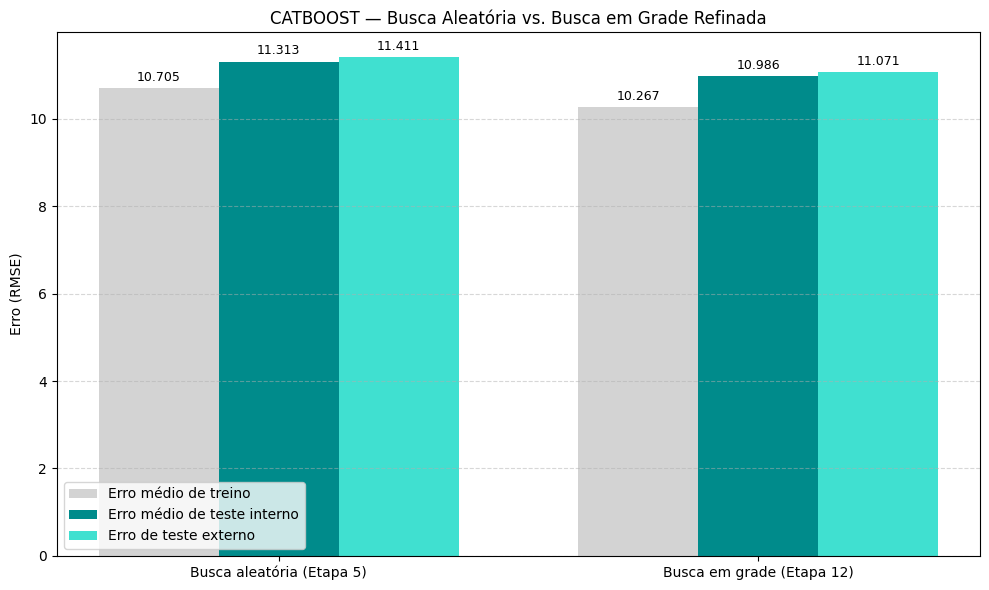

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 54 — Gráfico comparativo das duas estratégias de busca
# ==============================================================================
etapas_grafico = ["Busca aleatória (Etapa 5)", "Busca em grade (Etapa 12)"]
series_grafico = ["Erro médio de treino (RMSE)",
                  "Erro médio de teste interno (RMSE)",
                  "Erro de teste externo (RMSE)"]
cores_grafico = ["lightgray", "darkcyan", "turquoise"]

x_pos = np.arange(len(etapas_grafico))
largura_barra = 0.25

plt.figure(figsize=(10, 6))
for i, (serie, cor) in enumerate(zip(series_grafico, cores_grafico)):
    valores = [comparacao_buscas.loc[serie, etapa] for etapa in etapas_grafico]
    barras = plt.bar(x_pos + (i - 1) * largura_barra, valores,
                     width=largura_barra, label=serie.replace(" (RMSE)", ""), color=cor)
    plt.bar_label(barras, fmt="%.3f", padding=3, fontsize=9)

plt.xticks(x_pos, etapas_grafico)
plt.ylabel("Erro (RMSE)")
plt.title(f"{NOME_ALGORITMO_CAMPEAO} — Busca Aleatória vs. Busca em Grade Refinada")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Foi construído um gráfico de barras comparando os três erros (treino, teste interno e teste
# externo) das duas estratégias de busca, no mesmo padrão visual usado no Bloco 32.

### **Etapa 13: Modelo final — escolha, reajuste e avaliação**

*Este é o **único** ponto do notebook em que o modelo final é definido e reajustado. A decisão usa o erro médio de teste interno (validação cruzada) como critério — o mesmo da Etapa 7 —, e o conjunto de teste externo entra apenas depois, para medir o desempenho do modelo já escolhido.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 55 — Escolha do modelo final e reajuste no conjunto de treino completo
# ==============================================================================
# Critério de escolha: menor erro médio de teste interno entre as duas estratégias de busca,
# considerando apenas combinações aprovadas no filtro de superajuste da Etapa 6
if linha_grid is not None and float(linha_grid['media_erro_teste_interno']) < rmse_cv_ancora:
    estrategia_final = "GridSearchCV (grade refinada — Etapa 12)"
    hiperparametros_finais = dict(linha_grid['hiperparametros'])
    rmse_cv_final = float(linha_grid['media_erro_teste_interno'])
else:
    estrategia_final = "RandomizedSearchCV (busca aleatória — Etapa 5)"
    hiperparametros_finais = dict(hiperparametros_ancora)
    rmse_cv_final = rmse_cv_ancora

# Reajuste do modelo final no conjunto de treino completo (mesmo procedimento do Bloco 24)
modelo_final = clone(classe_campea).set_params(**hiperparametros_finais)
modelo_final.fit(X_treino_campeao, y_treino, **fit_kwargs_campeao)

print("=" * 78)
print("MODELO FINAL")
print("=" * 78)
print(f"\nAlgoritmo:  {NOME_ALGORITMO_CAMPEAO}")
print(f"Estratégia: {estrategia_final}")
print(f"Erro médio de teste interno (RMSE): {rmse_cv_final:.4f}")
print("\nHiperparâmetros:")
for parametro, valor in hiperparametros_finais.items():
    print(f"  {parametro}: {valor}")

modelo_final

# O modelo final foi escolhido entre as duas estratégias de busca pelo menor erro médio de
# teste interno e reajustado no conjunto de treino completo, com os hiperparâmetros vencedores.
# Todas as análises seguintes (métricas, resíduos, importância das variáveis e predição de
# novas observações) usam este mesmo objeto 'modelo_final'.

MODELO FINAL

Algoritmo:  CATBOOST
Estratégia: GridSearchCV (grade refinada — Etapa 12)
Erro médio de teste interno (RMSE): 10.9860

Hiperparâmetros:
  depth: 3
  iterations: 213
  l2_leaf_reg: 0.17893838
  learning_rate: 0.03410122
  subsample: 0.734218


CatBoostRegressor(depth=3, iterations=213, l2_leaf_reg=0.17893838, learning_rate=0.03410122, logging_level='Silent', loss_function='RMSE', random_state=123, subsample=0.734218)

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 56 — Métricas do modelo final no teste externo
# ==============================================================================
y_hat_teste_final = modelo_final.predict(X_teste_campeao)

def calcular_metricas(y_real, y_predito):
    return {
        "RMSE": root_mean_squared_error(y_real, y_predito),
        "MAE": np.mean(np.abs(y_real - y_predito)),
        "MAPE": np.mean(np.abs((y_real - y_predito) / y_real)),
        "R²": r2_score(y_real, y_predito)
    }

metricas_finais = pd.DataFrame({
    f"{NOME_ALGORITMO_CAMPEAO} — busca aleatória": calcular_metricas(y_teste, predicoes_teste[NOME_ALGORITMO_CAMPEAO]),
    f"{NOME_ALGORITMO_CAMPEAO} — modelo final": calcular_metricas(y_teste, y_hat_teste_final)
})
metricas_finais

# Foram calculadas as métricas de desempenho (RMSE, MAE, MAPE e R²) do modelo final no teste
# externo, ao lado das do modelo escolhido na Etapa 7 — permitindo verificar se o ganho obtido
# na validação cruzada se confirma em dados nunca vistos pelo modelo.

,CATBOOST — busca aleatória,CATBOOST — modelo final
RMSE,11.411,11.071
MAE,8.897,8.625
MAPE,0.225,0.212
R²,0.697,0.715


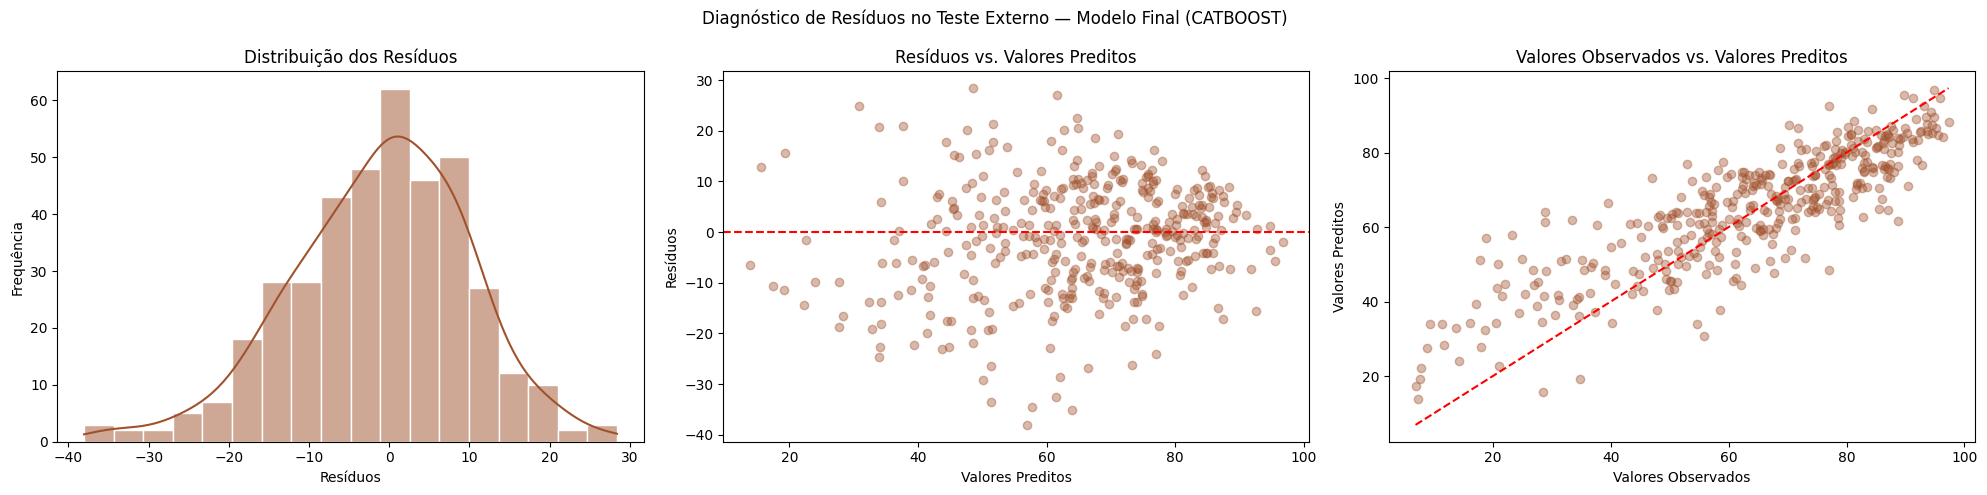

Média dos resíduos:        -1.1603
Desvio padrão dos resíduos: 11.0236


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 57 — Diagnóstico de resíduos do modelo final
# ==============================================================================
residuos_final = y_teste - y_hat_teste_final
cor_final = CORES[NOME_ALGORITMO_CAMPEAO]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Histograma dos resíduos
sns.histplot(residuos_final, color=cor_final, edgecolor="white", kde=True, ax=axes[0])
axes[0].set_title("Distribuição dos Resíduos")
axes[0].set_xlabel("Resíduos")
axes[0].set_ylabel("Frequência")

# Resíduos vs. valores preditos
axes[1].scatter(y_hat_teste_final, residuos_final, color=cor_final, alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Resíduos vs. Valores Preditos")
axes[1].set_xlabel("Valores Preditos")
axes[1].set_ylabel("Resíduos")

# Observado vs. predito
min_eixo = min(y_teste.min(), y_hat_teste_final.min())
max_eixo = max(y_teste.max(), y_hat_teste_final.max())
axes[2].scatter(y_teste, y_hat_teste_final, color=cor_final, alpha=0.4)
axes[2].plot([min_eixo, max_eixo], [min_eixo, max_eixo], color='red', linestyle='--')
axes[2].set_title("Valores Observados vs. Valores Preditos")
axes[2].set_xlabel("Valores Observados")
axes[2].set_ylabel("Valores Preditos")

plt.suptitle(f"Diagnóstico de Resíduos no Teste Externo — Modelo Final ({NOME_ALGORITMO_CAMPEAO})")
plt.tight_layout()
plt.show()

print(f"Média dos resíduos:        {residuos_final.mean():.4f}")
print(f"Desvio padrão dos resíduos: {residuos_final.std():.4f}")

# Foi construído o painel de diagnóstico do modelo final: histograma dos resíduos (verifica
# simetria em torno de zero), resíduos vs. preditos (verifica padrões e heterocedasticidade) e
# observado vs. predito com a reta de 45° (verifica o ajuste global).

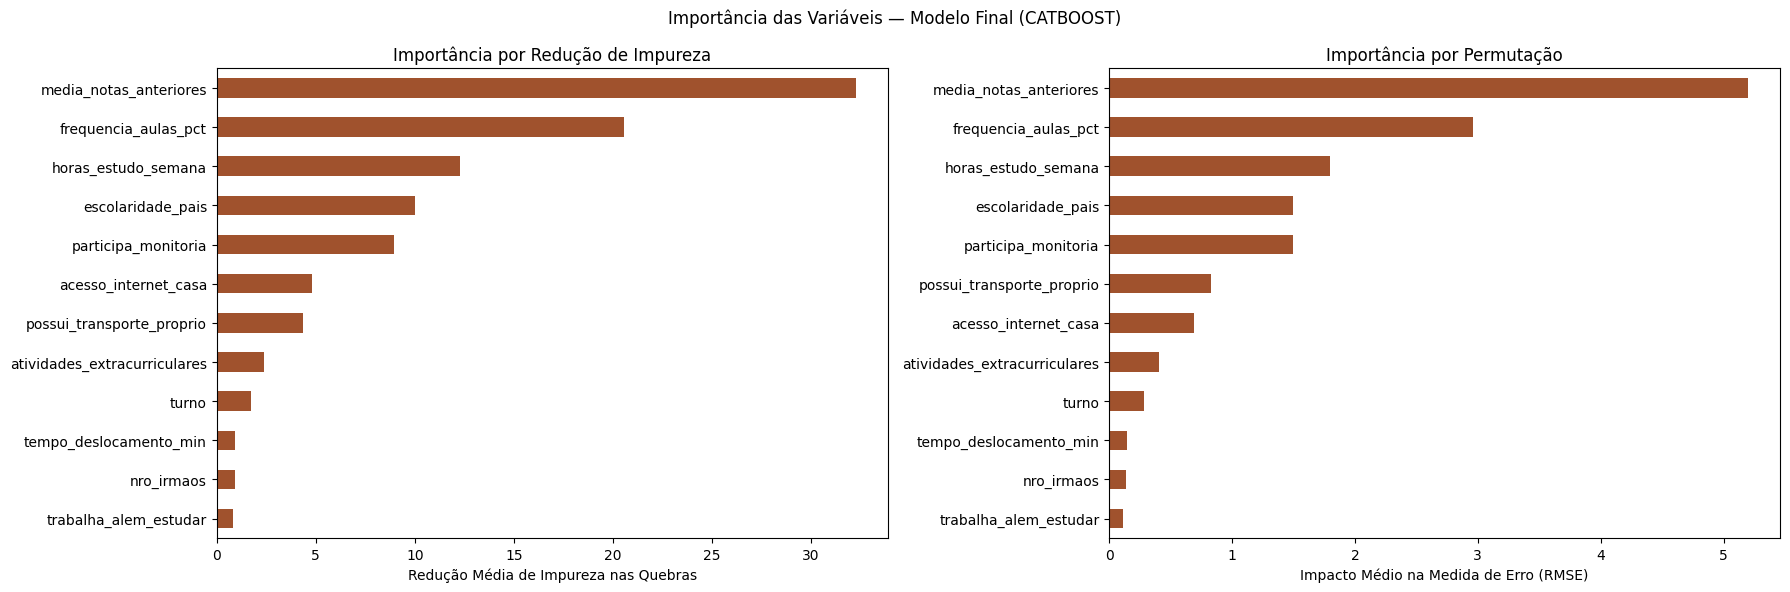

,Impureza,Permutação,Rank impureza,Rank permutação
media_notas_anteriores,32.247,5.200,1.000,1.000
frequencia_aulas_pct,20.562,2.964,2.000,2.000
horas_estudo_semana,12.302,1.795,3.000,3.000
escolaridade_pais,9.986,1.498,4.000,4.000
participa_monitoria,8.942,1.498,5.000,5.000
acesso_internet_casa,4.794,0.690,6.000,7.000
possui_transporte_proprio,4.359,0.831,7.000,6.000
atividades_extracurriculares,2.407,0.406,8.000,8.000
turno,1.724,0.279,9.000,9.000
tempo_deslocamento_min,0.945,0.144,10.000,10.000


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 58 — Importância das variáveis do modelo final (impureza e permutação)
# ==============================================================================
importancia_impureza_final = pd.Series(modelo_final.feature_importances_,
                                       index=X_treino_campeao.columns)

resultado_perm_final = permutation_importance(modelo_final,
                                              X_treino_campeao,
                                              y_treino,
                                              n_repeats=30,
                                              random_state=123,
                                              scoring='neg_root_mean_squared_error')
importancia_permutacao_final = pd.Series(resultado_perm_final.importances_mean,
                                         index=X_treino_campeao.columns)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

importancia_impureza_final.sort_values().plot.barh(ax=axes[0], color=cor_final)
axes[0].set_title("Importância por Redução de Impureza")
axes[0].set_xlabel("Redução Média de Impureza nas Quebras")

importancia_permutacao_final.sort_values().plot.barh(ax=axes[1], color=cor_final)
axes[1].set_title("Importância por Permutação")
axes[1].set_xlabel("Impacto Médio na Medida de Erro (RMSE)")

plt.suptitle(f"Importância das Variáveis — Modelo Final ({NOME_ALGORITMO_CAMPEAO})")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "Impureza": importancia_impureza_final,
    "Permutação": importancia_permutacao_final,
    "Rank impureza": importancia_impureza_final.rank(ascending=False),
    "Rank permutação": importancia_permutacao_final.rank(ascending=False)
}).sort_values("Impureza", ascending=False))

# Foram recalculadas, para o modelo final, as importâncias por redução de impureza e por
# permutação — as mesmas medidas da Etapa 11, agora aplicadas ao modelo efetivamente
# escolhido. As colunas de rank permitem verificar se os dois critérios concordam.

/tmp/ipykernel_596/1346011573.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_final, X_treino_campeao,


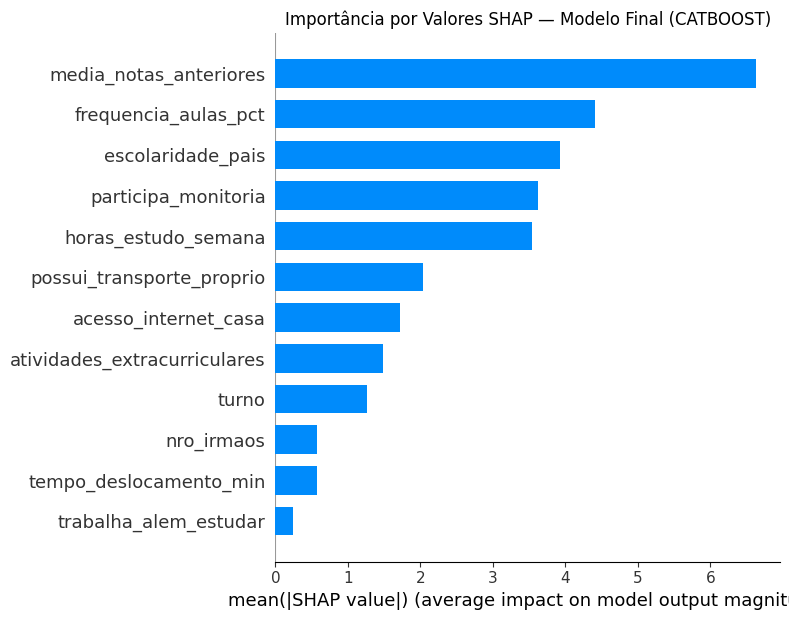

/tmp/ipykernel_596/1346011573.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_final, X_treino_campeao, max_display=15, show=False)


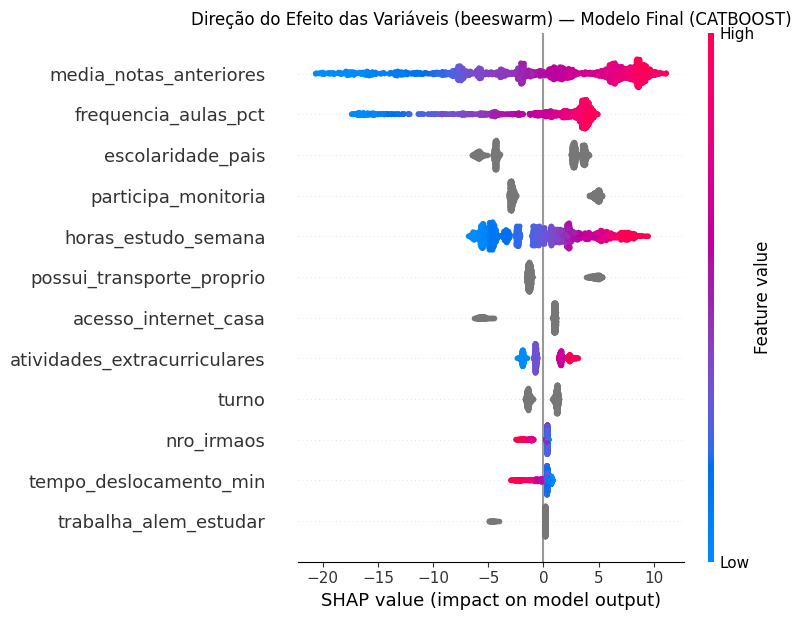

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 59 — Valores SHAP do modelo final (magnitude e direção do efeito)
# ==============================================================================
explicador_final = shap.TreeExplainer(modelo_final)
valores_shap_final = explicador_final(X_treino_campeao, check_additivity=False)

# Magnitude média do efeito de cada variável
shap.summary_plot(valores_shap_final, X_treino_campeao,
                  plot_type="bar", max_display=15, show=False)
plt.title(f"Importância por Valores SHAP — Modelo Final ({NOME_ALGORITMO_CAMPEAO})")
plt.tight_layout()
plt.show()

# Direção do efeito de cada variável, observação a observação
shap.summary_plot(valores_shap_final, X_treino_campeao, max_display=15, show=False)
plt.title(f"Direção do Efeito das Variáveis (beeswarm) — Modelo Final ({NOME_ALGORITMO_CAMPEAO})")
plt.tight_layout()
plt.show()

# Foram calculados os valores SHAP do modelo final e exibidos em dois gráficos: o de barras,
# com o valor absoluto médio de SHAP por variável (magnitude do efeito, em pontos da nota
# final), e o beeswarm, que mostra a direção do efeito — pontos à direita do zero empurram a
# nota prevista para cima, e a cor indica se o valor da variável naquela observação é alto
# (vermelho) ou baixo (azul).

### **Etapa 14: Predição da nota final de novos alunos**

*Aplicação do modelo final a alunos que não estão na base, informando manualmente suas características. As variáveis qualitativas devem receber categorias existentes na base de treino; as quantitativas, valores na mesma escala e unidade das originais.*

In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 60 — Categorias válidas das variáveis qualitativas
# ==============================================================================
categorias_validas = {coluna: sorted(dados[coluna].dropna().unique().tolist())
                      for coluna in lista_X_quali}

print("=" * 78)
print("CATEGORIAS OBSERVADAS NA BASE (valores aceitos pelo modelo)")
print("=" * 78)
for coluna, valores in categorias_validas.items():
    print(f"\n{coluna}:")
    print(f"  {valores}")

print("\n" + "=" * 78)
print("FAIXA DAS VARIÁVEIS QUANTITATIVAS")
print("=" * 78)
display(dados[lista_X_quanti].describe().T[['min', 'mean', 'max']])

# Foram listadas as categorias observadas em cada variável qualitativa e as faixas de valores
# das quantitativas, para orientar o preenchimento das características dos novos alunos no
# bloco seguinte e evitar categorias inexistentes ou valores fora da faixa da base.

CATEGORIAS OBSERVADAS NA BASE (valores aceitos pelo modelo)

escolaridade_pais:
  ['fundamental', 'medio', 'mestrado-doutorado', 'pos_graduacao', 'superior']

acesso_internet_casa:
  ['nao', 'sim']

participa_monitoria:
  ['nao', 'sim']

trabalha_alem_estudar:
  ['nao', 'sim']

turno:
  ['manha', 'tarde']

possui_transporte_proprio:
  ['nao', 'sim']

FAIXA DAS VARIÁVEIS QUANTITATIVAS


,min,mean,max
horas_estudo_semana,0.000,14.761,40.000
frequencia_aulas_pct,32.100,85.448,100.000
media_notas_anteriores,1.900,65.163,100.000
atividades_extracurriculares,0.000,1.326,5.000
tempo_deslocamento_min,1.000,26.123,120.000
nro_irmaos,0.000,1.570,6.000


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 61 — Definição das características dos novos alunos
# ==============================================================================
# Altere livremente os valores abaixo; use as categorias listadas no Bloco 60
novos_alunos = pd.DataFrame([

    # Aluno A — perfil favorável: muitas horas de estudo, alta frequência, boa base anterior
    {
        'escolaridade_pais': 'superior',
        'acesso_internet_casa': 'sim',
        'participa_monitoria': 'sim',
        'trabalha_alem_estudar': 'nao',
        'turno': 'manha',
        'possui_transporte_proprio': 'sim',
        'horas_estudo_semana': 20,
        'frequencia_aulas_pct': 95.0,
        'media_notas_anteriores': 85.0,
        'atividades_extracurriculares': 2,
        'tempo_deslocamento_min': 15,
        'nro_irmaos': 1
    },

    # Aluno B — perfil desafiador: poucas horas de estudo, trabalha, deslocamento longo
    {
        'escolaridade_pais': 'fundamental',
        'acesso_internet_casa': 'nao',
        'participa_monitoria': 'nao',
        'trabalha_alem_estudar': 'sim',
        'turno': 'tarde',
        'possui_transporte_proprio': 'nao',
        'horas_estudo_semana': 5,
        'frequencia_aulas_pct': 70.0,
        'media_notas_anteriores': 55.0,
        'atividades_extracurriculares': 0,
        'tempo_deslocamento_min': 60,
        'nro_irmaos': 3
    },

])

# Conferência 1: as colunas devem ser exatamente as mesmas de X, na mesma ordem
colunas_modelo = lista_X_quali + lista_X_quanti
faltantes = [c for c in colunas_modelo if c not in novos_alunos.columns]
extras = [c for c in novos_alunos.columns if c not in colunas_modelo]
if faltantes:
    raise ValueError(f"Faltam características nos novos alunos: {faltantes}")
if extras:
    raise ValueError(f"Foram informadas características desconhecidas: {extras}")
novos_alunos = novos_alunos[colunas_modelo].copy()

# Conferência 2: as categorias informadas devem existir na base
for coluna in lista_X_quali:
    invalidos = set(novos_alunos[coluna].astype(str)) - set(map(str, categorias_validas[coluna]))
    if invalidos:
        raise ValueError(f"Categoria inexistente em '{coluna}': {invalidos}. "
                         f"Valores aceitos: {categorias_validas[coluna]}")

novos_alunos

# Foram definidas as características de dois novos alunos com perfis contrastantes e
# verificadas duas condições antes da predição: que as colunas são exatamente as mesmas usadas
# na construção de X (na mesma ordem) e que todas as categorias informadas existem na base.

,escolaridade_pais,acesso_internet_casa,participa_monitoria,trabalha_alem_estudar,turno,possui_transporte_proprio,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos
0,superior,sim,sim,nao,manha,sim,20,95.000,85.000,2,15,1
1,fundamental,nao,nao,sim,tarde,nao,5,70.000,55.000,0,60,3


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 62 — Predição da nota final dos novos alunos
# ==============================================================================
# O pré-processamento aplicado aos novos alunos é o mesmo do algoritmo campeão: o CatBoost
# usa os dados brutos; os demais algoritmos passam pelo 'preprocessador' ajustado no treino
if tipo_dado_campeao == 'tratada':
    novos_alunos_uso = pd.DataFrame(preprocessador.transform(novos_alunos),
                                    columns=nomes_variaveis)
else:
    novos_alunos_uso = novos_alunos

notas_previstas = modelo_final.predict(novos_alunos_uso)

previsoes_novos_alunos = novos_alunos.copy()
previsoes_novos_alunos.insert(0, "aluno", [f"Aluno {chr(65 + i)}" for i in range(len(novos_alunos))])
previsoes_novos_alunos["nota_final_prevista"] = notas_previstas.round(2)

display(previsoes_novos_alunos[["aluno"] + colunas_modelo + ["nota_final_prevista"]])

print("=" * 78)
print("PREVISÃO DA NOTA FINAL")
print("=" * 78)
for _, linha in previsoes_novos_alunos.iterrows():
    print(f"{linha['aluno']}: nota final prevista = {linha['nota_final_prevista']:.2f} "
          f"(margem típica de erro de ± {metricas_finais.loc['RMSE'].iloc[-1]:.1f} pontos, medida pelo RMSE de teste externo)")

# O modelo final foi aplicado aos novos alunos, gerando a nota prevista de cada um. A margem
# apresentada ao lado da predição é o RMSE do teste externo: uma estimativa realista de quanto
# a nota observada tende a se afastar da prevista, e que deve acompanhar qualquer leitura
# gerencial do resultado.

,aluno,escolaridade_pais,acesso_internet_casa,participa_monitoria,trabalha_alem_estudar,turno,possui_transporte_proprio,horas_estudo_semana,frequencia_aulas_pct,media_notas_anteriores,atividades_extracurriculares,tempo_deslocamento_min,nro_irmaos,nota_final_prevista
0,Aluno A,superior,sim,sim,nao,manha,sim,20,95.000,85.000,2,15,1,94.350
1,Aluno B,fundamental,nao,nao,sim,tarde,nao,5,70.000,55.000,0,60,3,21.980


PREVISÃO DA NOTA FINAL
Aluno A: nota final prevista = 94.35 (margem típica de erro de ± 11.1 pontos, medida pelo RMSE de teste externo)
Aluno B: nota final prevista = 21.98 (margem típica de erro de ± 11.1 pontos, medida pelo RMSE de teste externo)


In [ ]:
# ==============================================================================
# BLOCO DE CÓDIGO 63 — Resumo executivo dos resultados
# ==============================================================================
print("=" * 78)
print("RESUMO EXECUTIVO — CASE H: DESEMPENHO ESCOLAR")
print("=" * 78)

print("\n1) COMPARAÇÃO ENTRE ALGORITMOS (teste externo)")
display(metricas_teste_externo.T.sort_values("RMSE"))

print("\n2) REFINAMENTO DO ALGORITMO CAMPEÃO")
print(f"   Algoritmo campeão: {NOME_ALGORITMO_CAMPEAO}")
print(f"   Busca aleatória  — RMSE de teste interno: {rmse_cv_ancora:.4f}")
if linha_grid is not None:
    print(f"   Busca em grade   — RMSE de teste interno: {float(linha_grid['media_erro_teste_interno']):.4f}")
print(f"   Estratégia vencedora: {estrategia_final}")

print("\n3) MODELO FINAL — HIPERPARÂMETROS")
for parametro, valor in hiperparametros_finais.items():
    print(f"   {parametro}: {valor}")

print("\n4) MODELO FINAL — DESEMPENHO NO TESTE EXTERNO")
for metrica, valor in metricas_finais.iloc[:, -1].items():
    print(f"   {metrica}: {valor:.4f}")

print("\n5) VARIÁVEIS MAIS INFLUENTES (por permutação)")
for variavel, valor in importancia_permutacao_final.sort_values(ascending=False).head(5).items():
    print(f"   {variavel}: {valor:.4f}")

# Foi impresso um resumo consolidado com os números que sustentam a apresentação: o ranking dos
# algoritmos, o resultado do refinamento, a configuração e o desempenho do modelo final e as
# variáveis mais influentes. Use estes valores para preencher os slides e a conclusão.

RESUMO EXECUTIVO — CASE H: DESEMPENHO ESCOLAR

1) COMPARAÇÃO ENTRE ALGORITMOS (teste externo)


,RMSE,MAE,MAPE,R²
CATBOOST,11.411,8.897,0.225,0.697
GRADIENT BOOSTING,12.599,9.696,0.260,0.631
LIGHTGBM,13.050,10.157,0.278,0.604
FLORESTA ALEATÓRIA,13.092,10.206,0.265,0.601
ADABOOST,13.222,10.435,0.267,0.593
XGBOOST,13.777,10.843,0.295,0.559
GRADIENT BOOSTING COM HISTOGRAMAS,13.858,10.843,0.301,0.553
ÁRVORE DE REGRESSÃO,14.760,11.578,0.293,0.493



2) REFINAMENTO DO ALGORITMO CAMPEÃO
   Algoritmo campeão: CATBOOST
   Busca aleatória  — RMSE de teste interno: 11.3131
   Busca em grade   — RMSE de teste interno: 10.9860
   Estratégia vencedora: GridSearchCV (grade refinada — Etapa 12)

3) MODELO FINAL — HIPERPARÂMETROS
   depth: 3
   iterations: 213
   l2_leaf_reg: 0.17893838
   learning_rate: 0.03410122
   subsample: 0.734218

4) MODELO FINAL — DESEMPENHO NO TESTE EXTERNO
   RMSE: 11.0707
   MAE: 8.6247
   MAPE: 0.2117
   R²: 0.7150

5) VARIÁVEIS MAIS INFLUENTES (por permutação)
   media_notas_anteriores: 5.1996
   frequencia_aulas_pct: 2.9636
   horas_estudo_semana: 1.7949
   escolaridade_pais: 1.4979
   participa_monitoria: 1.4978


### **Conclusão**

## Conclusão

### 1. Predição — qual algoritmo prevê a nota final com o menor erro

Entre os oito algoritmos comparados sob a mesma base, a mesma divisão treino/teste e a mesma estratégia de validação cruzada, o **CatBoost** foi o mais preciso, com folga: RMSE de **11,41** no teste externo contra 12,60 do segundo colocado (Gradient Boosting) e 14,76 da Árvore de Regressão isolada.

O refinamento por **busca em grade** (Etapa 12), com 405 combinações construídas ao redor do modelo campeão da Etapa 7, produziu ganho consistente:

| | Busca aleatória (Etapa 5) | **Modelo final (grade)** |
|---|---|---|
| RMSE teste interno | 11,313 | **10,986** (−2,89%) |
| RMSE teste externo | 11,411 | **11,071** |
| MAE teste externo | 8,897 | **8,625** |
| MAPE teste externo | 22,5% | **21,2%** |
| R² teste externo | 0,697 | **0,715** |

Três observações sobre esse resultado:

- **O ganho se confirmou fora da amostra.** Melhorar na validação cruzada e piorar no teste externo seria sinal de ajuste às particularidades das folds. Aqui as duas medidas caminharam juntas, o que sustenta a escolha.
- **A configuração vencedora ficou próxima da âncora** — manteve `depth=3`, `l2_leaf_reg` e `subsample`, alterando apenas `iterations` (193 → 213) e `learning_rate` (0,0273 → 0,0341). Isso indica que a busca aleatória com 100 iterações já havia chegado perto do ótimo local; a grade extraiu o refinamento restante.
- **288 das 405 combinações (71%) passaram no filtro de superajuste**, e a variação percentual treino → teste interno do modelo final ficou *abaixo* da do modelo de partida. O ganho não veio às custas de mais superajuste.

**Modelo final:** CatBoost com `depth=3`, `iterations=213`, `learning_rate=0,0341`, `l2_leaf_reg=0,1789`, `subsample=0,7342`.

**Qual nota um novo aluno tende a obter.** Aplicado a dois perfis contrastantes (Etapa 14), o modelo previu **94,4** para um aluno com 20 h de estudo semanais, 95% de frequência, média anterior 85, participante de monitoria e pais com ensino superior; e **22,0** para um aluno com 5 h de estudo, 70% de frequência, média anterior 55, que trabalha, sem internet em casa e com 60 min de deslocamento. Ambas as predições devem ser lidas com margem de **± 11,1 pontos** — o RMSE do teste externo.

### 2. Interpretação — o que mais influencia a nota final

Os três critérios (redução de impureza, permutação e valores SHAP) produzem rankings praticamente idênticos — divergem apenas na 6ª e 7ª posições, entre `acesso_internet_casa` e `possui_transporte_proprio`. Essa convergência é relevante: a importância por impureza costuma inflar variáveis com muitas categorias, e aqui isso não ocorreu.

| Variável | \|SHAP\| médio | Direção do efeito |
|---|---|---|
| `media_notas_anteriores` | 6,63 | ↑ nota anterior mais alta, nota final maior |
| `frequencia_aulas_pct` | 4,41 | ↑ mais frequência, nota maior |
| `escolaridade_pais` | 3,93 | fundamental −5,9 · médio −4,3 · superior +2,7 · pós/mestrado +3,7 |
| `participa_monitoria` | 3,62 | sim **+4,9** · não −2,9 |
| `horas_estudo_semana` | 3,54 | ↑ mais horas, nota maior |
| `possui_transporte_proprio` | 2,04 | sim +4,7 · não −1,3 |
| `acesso_internet_casa` | 1,72 | não **−5,6** · sim +1,0 |
| `atividades_extracurriculares` | 1,49 | ↑ leve efeito positivo |
| `turno` | 1,27 | manhã +1,2 · tarde −1,4 |
| `nro_irmaos` | 0,58 | ↓ efeito negativo fraco |
| `tempo_deslocamento_min` | 0,57 | ↓ efeito negativo fraco |
| `trabalha_alem_estudar` | 0,25 | sim −4,6, mas em apenas 42 alunos |

**Duas leituras com valor pedagógico:**

**Monitoria é a variável de maior efeito entre as que a escola controla diretamente.** As três primeiras do ranking — desempenho anterior, frequência e escolaridade dos pais — são histórico ou contexto familiar. A participação em monitoria vale, em média, **+4,9 pontos** na predição, e apenas 37% dos alunos participam.

**A ausência de internet em casa custa −5,6 pontos** e atinge 15% dos alunos (245 no conjunto de treino). É um gargalo de infraestrutura, não de esforço — e o tipo de restrição que uma ação pontual pode remover.

### 3. Ressalvas

- **Associação não é causalidade.** O modelo descreve padrões observados; não garante que colocar um aluno em monitoria produza +4,9 pontos. É plausível que alunos que buscam monitoria já sejam mais engajados, e que parte do efeito medido seja desse engajamento prévio. Uma verificação adequada exigiria desenho experimental ou quasi-experimental.
- **`trabalha_alem_estudar` não sustenta conclusão.** O efeito individual é grande (−4,6), mas a variável tem apenas 42 casos positivos no treino — o que explica sua penúltima posição no ranking de importância global. Amostra insuficiente.
- **O modelo superestima ligeiramente.** A média dos resíduos no teste externo é **−1,16**, ou seja, as notas previstas ficam em média ~1,2 ponto acima das observadas. É pequeno diante do RMSE de 11,1, mas é viés sistemático e não ruído: em uso operacional, alunos em risco tendem a ser classificados como um pouco melhores do que são.
- **MAPE de 21,2% exige leitura cuidadosa.** Por ser erro relativo, ele é inflado pelos alunos de nota baixa — errar 5 pontos vale 25% para quem tira 20 e 6% para quem tira 80. RMSE e MAE são as métricas mais informativas neste case.
- **Domínio de validade.** O desempenho medido vale para alunos que sigam os padrões da base. Perfis fora das faixas e categorias listadas no Bloco 60 estão fora do escopo do modelo.
- **Uso recomendado.** Com erro típico de ~11 pontos em uma escala de 0 a 100, o modelo serve para **priorizar grupos** de alunos em risco e orientar onde alocar apoio pedagógico — não para tratar a nota prevista de um aluno específico como estimativa precisa.